# Label Data
This notebook is made to label the data. To create correct labels for each of the testing experimental data examples in order to ensure the corectness of the runs.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))

from script.helper_methods.data_loader import load_raw_data
from script.helper_methods import data_preprocessing as dp
from script.helper_methods import data_visualization as dv


In [2]:
def save_labeled_data(df, name):
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
    LABELED_PATH = os.path.join(BASE_PATH, 'data', 'labeled')
    if not os.path.exists(LABELED_PATH):
        os.makedirs(LABELED_PATH)
    output_path = os.path.join(LABELED_PATH, f'labeled_{name}.csv')
    df.to_csv(output_path, index=True)
    print(f"Labeled data saved to {output_path}")

In [3]:
def set_default_plug(df):
    dp.create_target_column(df) # Makes plug = 1/0 column, based on flow/pressure threshold
    dp.create_future_target(df)

In [4]:
def set_no_plug(df):
    df['Plug'] = 0
    df['Plug_future'] = 0

In [5]:
def show_info(df):
    print(f"Dataset columns: {df.columns.tolist()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    df.index = pd.to_datetime(df.index)
    print("Duplicate index timestamps:", df.index.duplicated().sum())

    print(f"Datatypes:\n{df.dtypes}")
    
    return df.head()

In [6]:
def set_plug_at_time(df, time_start, time_end, custom_date=None):
    # find first plug
    start_time = f'1900-01-01 {time_start}.330000'
    end_time = f'1900-01-01 {time_end}.330000'

    if custom_date is not None:
        start_time = f'{custom_date} {time_start}.330000'
        end_time = f'{custom_date} {time_end}.330000'

    # set plug column
    if 'Plug' not in df.columns:
        df['Plug'] = 0  
    df['Plug'] = np.where((df.index >= start_time) & (df.index <= end_time), 1, df['Plug'])
    
    dp.create_future_target(df)

In [7]:
def add_logId_column(df, log_id):
    '''Add a LogId column to the dataframe to specify which log the data comes from'''
    df = df.copy()
    df['LogId'] = log_id
    return df

In [8]:
def cut(df, seconds_elapsed_start, seconds_elapsed_stop):
    start = df.index[0] + pd.Timedelta(seconds=seconds_elapsed_start)
    stop = df.index[0] + pd.Timedelta(seconds=seconds_elapsed_stop)
    
    return df[(df.index < start) | (df.index > stop)]

In [9]:
def flow_rate_missing(df, missing=False):
    '''Indicate whether flow rate is missing (1) or not (0), manually set based on visual inspection of the data'''
    df["flow_rate_missing"] = 1 if missing else 0
    return df

In [10]:
# Load the data
print("Loading datasets...")
dataset1 = load_raw_data()
dataset2 = load_raw_data(path="../data/raw_data/data2/*.csv")
dataset3 = load_raw_data(path="../data/raw_data/data3/*.csv")
dataset4 = load_raw_data(path="../data/raw_data/data4/*.csv")
dataset5 = load_raw_data(path="../data/raw_data/data5/*.csv")
dataset6 = load_raw_data(path="../data/raw_data/data6/*.csv")
dataset7 = load_raw_data(path="../data/raw_data/data7/*.csv")
dataset8 = load_raw_data(path="../data/raw_data/data8/*.csv")
dataset9 = load_raw_data(path="../data/raw_data/data9/*.csv")
dataset10 = load_raw_data(path="../data/raw_data/data10/*.csv")
dataset11 = load_raw_data(path="../data/raw_data/data11/*.csv")
dataset12 = load_raw_data(path="../data/raw_data/data12/*.csv")
# Second dataset
dataset13 = load_raw_data(path="../data/raw_data/data13/*.csv")
dataset14 = load_raw_data(path="../data/raw_data/data14/*.csv")
dataset15 = load_raw_data(path="../data/raw_data/data15/*.csv")
dataset16 = load_raw_data(path="../data/raw_data/data16/*.csv")
dataset17 = load_raw_data(path="../data/raw_data/data17/*.csv")
dataset18 = load_raw_data(path="../data/raw_data/data18/*.csv", reconstruct_time=True, start_time="11.03.2022 14:06:00", freq_Hz=20)
dataset19 = load_raw_data(path="../data/raw_data/data19/*.csv")
dataset20 = load_raw_data(path="../data/raw_data/data20/*.csv")
dataset21 = load_raw_data(path="../data/raw_data/data21/*.csv")
dataset22 = load_raw_data(path="../data/raw_data/data22/*.csv", reconstruct_time=True, start_time="15.03.2022 12:46:20", freq_Hz=20)
dataset23 = load_raw_data(path="../data/raw_data/data23/*.csv")
dataset24 = load_raw_data(path="../data/raw_data/data24/*.csv")
dataset25 = load_raw_data(path="../data/raw_data/data25/*.csv")

print("Datasets loaded.")

Loading datasets...
Datasets loaded.


In [11]:
dataset1.head(5)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


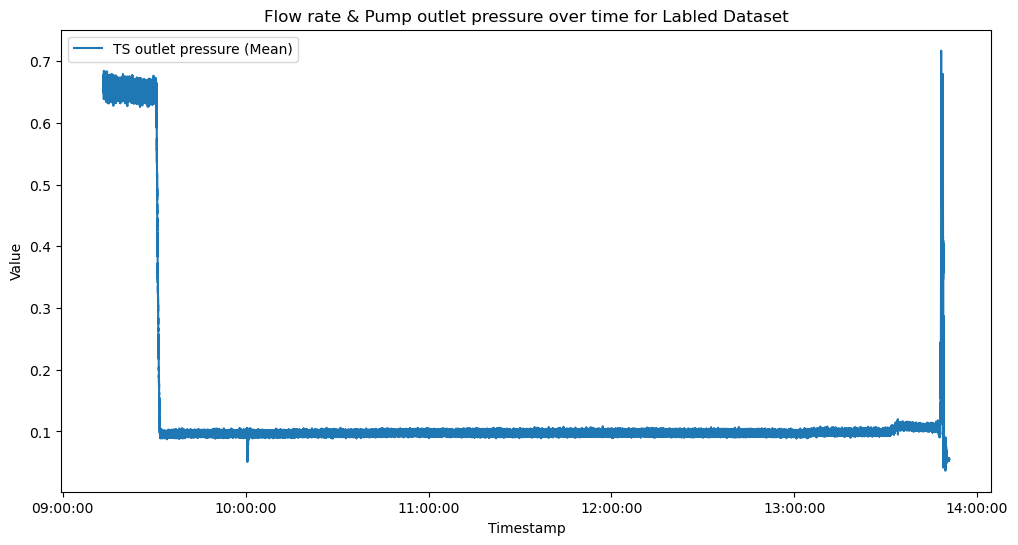

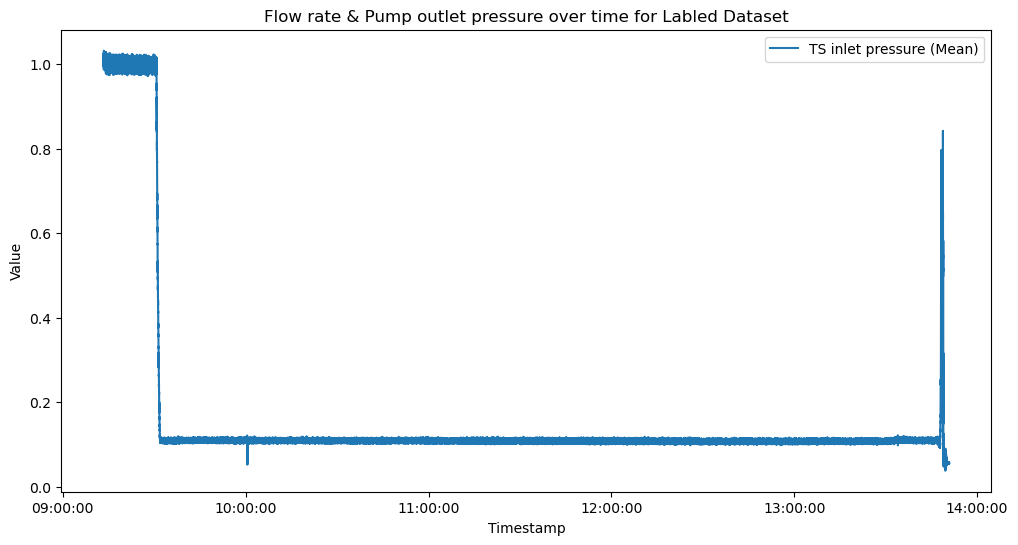

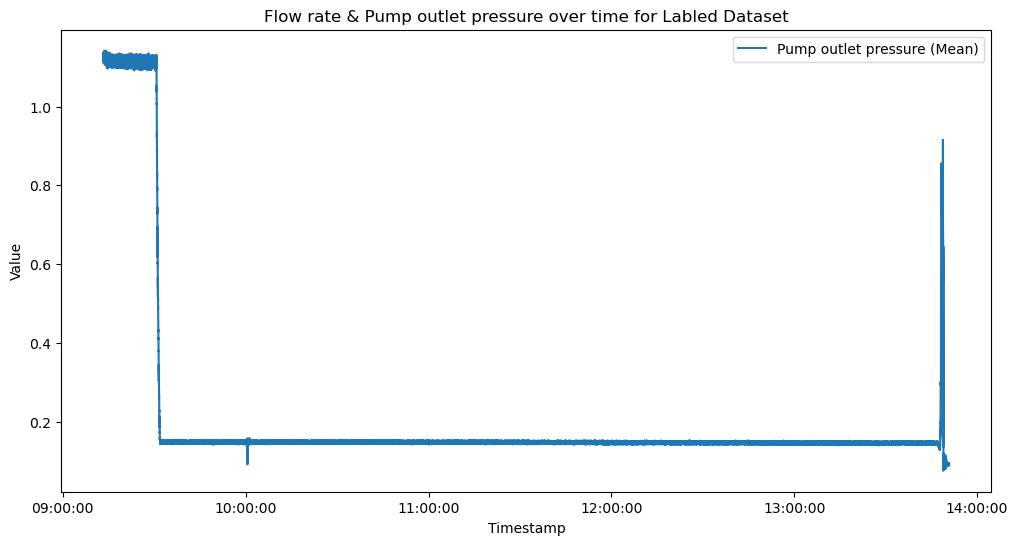

In [12]:
dv.visualize_key_column(dataset1, key="TS outlet pressure (Mean)", name="Labled Dataset")
dv.visualize_key_column(dataset1, key="TS inlet pressure (Mean)", name="Labled Dataset")
dv.visualize_key_column(dataset1, key="Pump outlet pressure (Mean)", name="Labled Dataset")

## For each dataset look at it and label it

# Dataset 1
Under are the new datasets gotten from the first datasets set.

⚙️ Flow threshold set to: 327.32


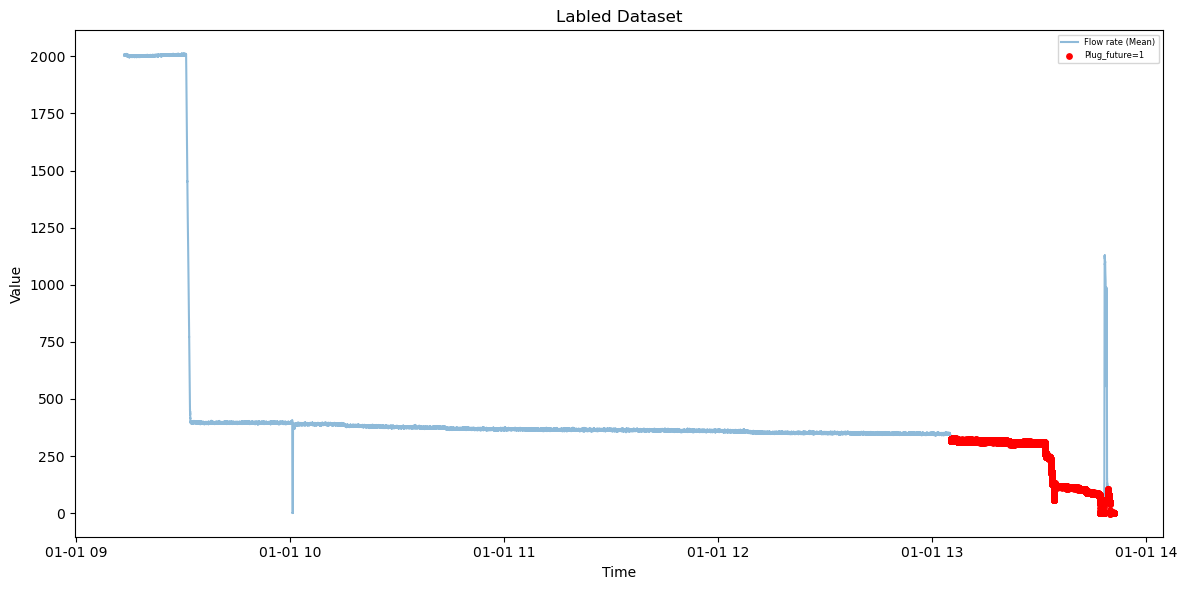

In [13]:
set_default_plug(dataset1)
dv.visualize_plug_event(dataset1, plug_column="Plug_future", name="Labled Dataset")

# Dataset 2

In [14]:
show_info(dataset2)

Dataset columns: ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)']
Duplicate rows: 21
Duplicate index timestamps: 0
Datatypes:
Flow rate (Mean)                float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Temperature TS outlet (Mean)    float64
Tank temperature (Mean)         float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
dtype: object


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 13:21:20.972,1848.384604,0.587711,0.883321,0.920769,-3.861375,-4.160188,-3.962189,24.195356
1900-01-01 13:21:20.982,1849.799046,0.586661,0.885422,1.039285,-3.940132,-4.448936,-4.211572,24.234738
1900-01-01 13:21:20.992,1850.270527,0.584561,0.888572,0.986918,-3.861375,-4.120814,-3.830935,24.221611
1900-01-01 13:21:21.002,1850.742008,0.586661,0.882271,0.963031,-3.992637,-4.448936,-4.132819,24.195356
1900-01-01 13:21:21.012,1850.742008,0.583511,0.874396,1.031935,-3.848249,-4.199563,-3.975314,24.287248


In [15]:
print("shape of dataset2:", dataset2.shape)

shape of dataset2: (2046277, 8)


⚙️ Flow threshold set to: 346.84


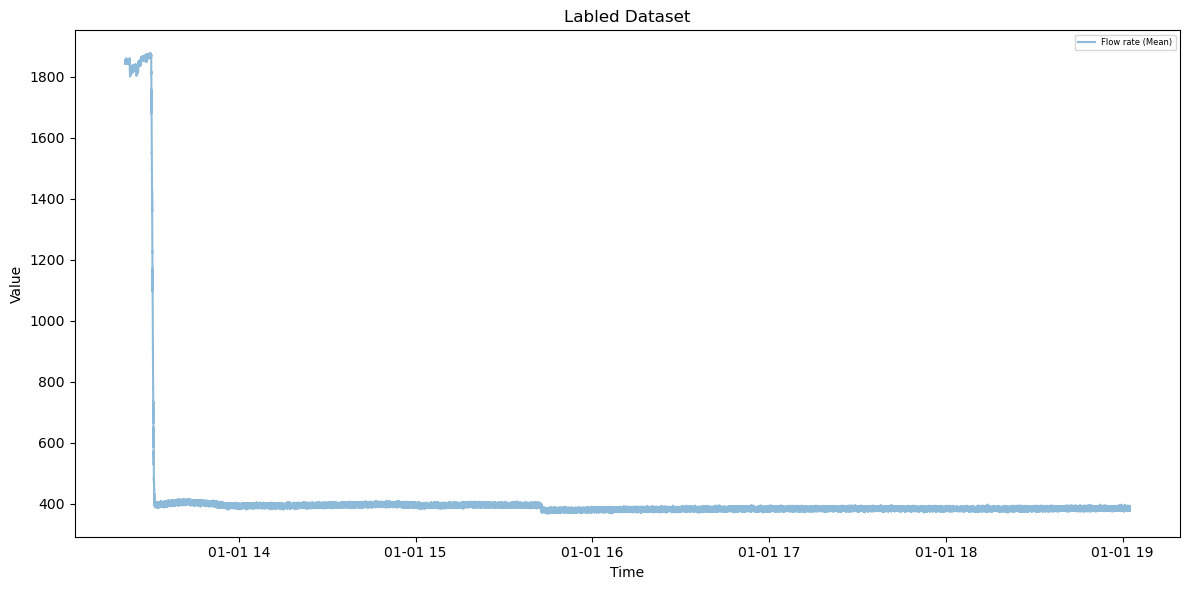

In [16]:
set_default_plug(dataset2)
dv.visualize_plug_event(dataset2, plug_column="Plug_future", name="Labled Dataset")

### Own notes on whether there was manual changes in this experiment !! TODO
Based on the visualization it doesnt look like any manual alternations were made during this experiment. We can see a fall of flow rate at the start but this is probably just caused by the start of the system. 

# Dataset 3

In [17]:
show_info(dataset3)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-09-01 10:08:28.347,0.759556,0.000932,0.212329,1561.091208,7.280965,-2.381982,-0.025701,21.950240,0.241412,0.649763,0.230938,1.075645,0.017048,0.083666,0.005487,11.664282
2021-09-01 10:08:28.846,0.760145,0.000721,0.213470,1560.987274,7.231516,-2.370934,-0.125659,21.969181,0.269339,0.664583,0.236032,1.083438,0.016058,0.090984,0.005661,12.519271
2021-09-01 10:08:29.350,0.758179,0.000997,0.213269,1562.163933,7.182435,-2.299218,-0.214808,21.954802,0.257213,0.630675,0.242421,1.112259,0.016666,0.095589,0.005747,11.097039
2021-09-01 10:08:29.848,0.760242,0.000642,0.212117,1563.040239,7.017590,-2.263474,-0.313047,21.937244,0.279101,0.723726,0.245817,1.062527,0.016441,0.111216,0.005620,11.240369
2021-09-01 10:08:30.347,0.759019,0.000795,0.212366,1561.894331,7.095533,-2.231526,-0.370821,21.960763,0.266585,0.612376,0.251867,1.087259,0.016192,0.112690,0.005541,11.301572


In [18]:
# cut the first 3200s from dataset3
dataset3 = dataset3.iloc[3200:]
set_no_plug(dataset3)

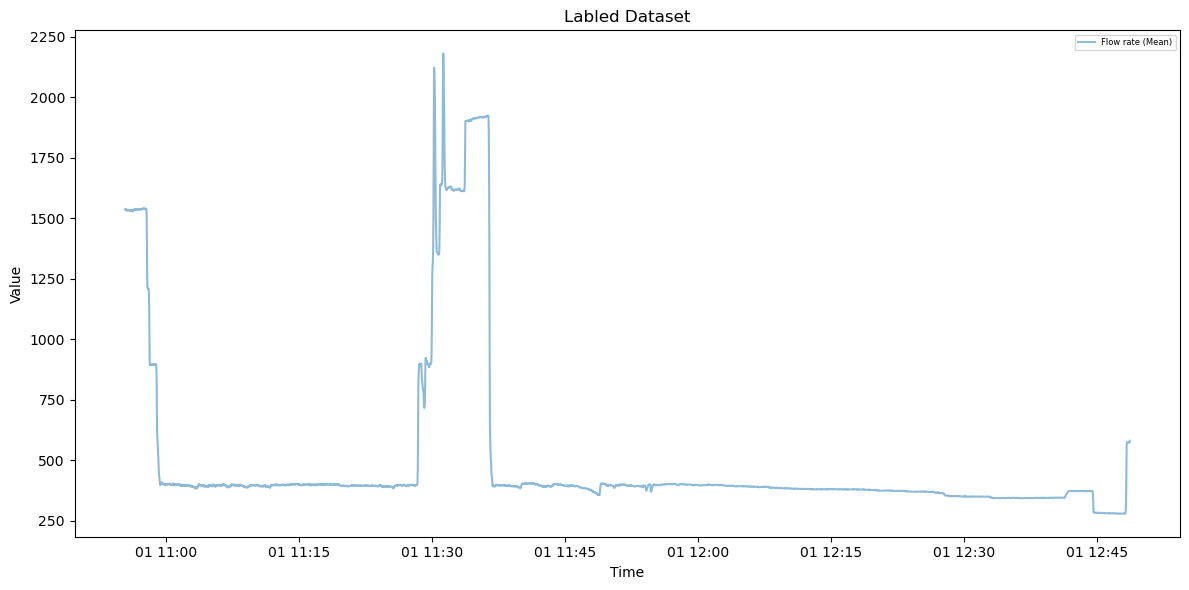

In [19]:
dv.visualize_plug_event(dataset3, plug_column="Plug_future", name="Labled Dataset")

### Own notes on whether there was manual changes in this experiment !! TODO
The start of the experiment looks like is just caused by the startup of the system, should i move the datalog to where it has stabilized?



# Data 4
No blockage

without flow rate measure?

In [20]:
show_info(dataset4)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 15:14:08.717,21.289102,-7.686529,21.978412,-7.887004,0.234429,0.241925,0.430600,1.023696
1900-01-01 15:14:09.717,21.273088,-7.692305,21.964366,-7.885036,0.233763,0.241222,0.430003,1.000122
1900-01-01 15:14:10.717,21.281620,-7.690073,21.969485,-7.881623,0.233689,0.240896,0.431041,0.957688
1900-01-01 15:14:11.717,21.273613,-7.691123,21.965547,-7.872829,0.234797,0.243133,0.432006,0.849248
1900-01-01 15:14:12.717,21.278076,-7.700311,21.966991,-7.865742,0.234015,0.241999,0.430940,0.594648


In [21]:
dataset4 = flow_rate_missing(dataset4, missing=True)

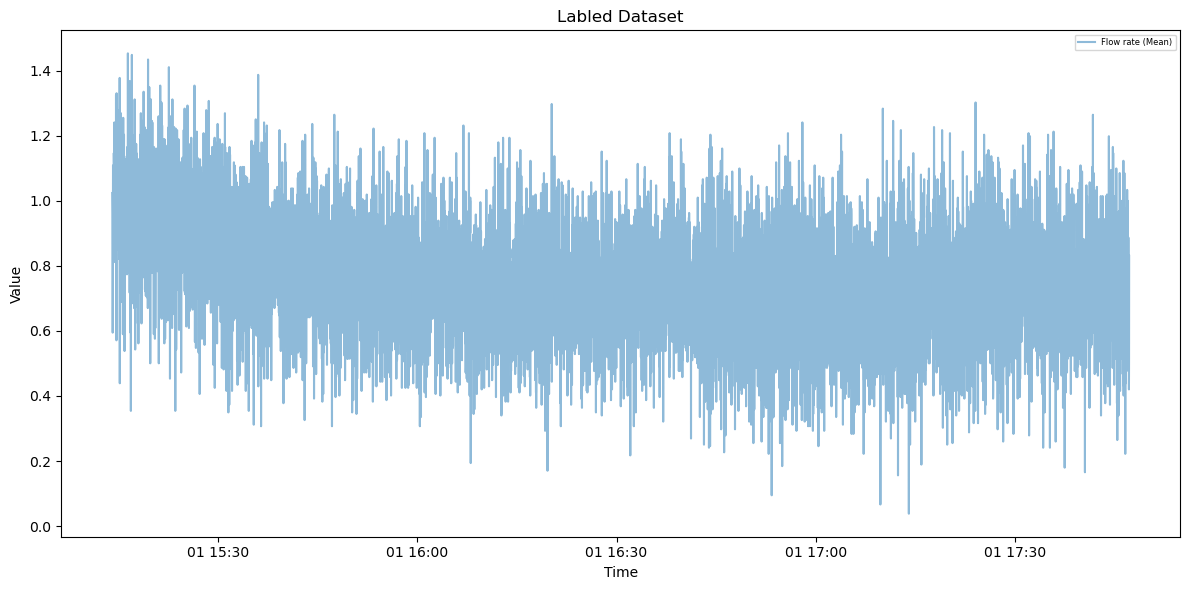

In [22]:
set_no_plug(dataset4)
dv.visualize_plug_event(dataset4, plug_column="Plug_future", name="Labled Dataset")

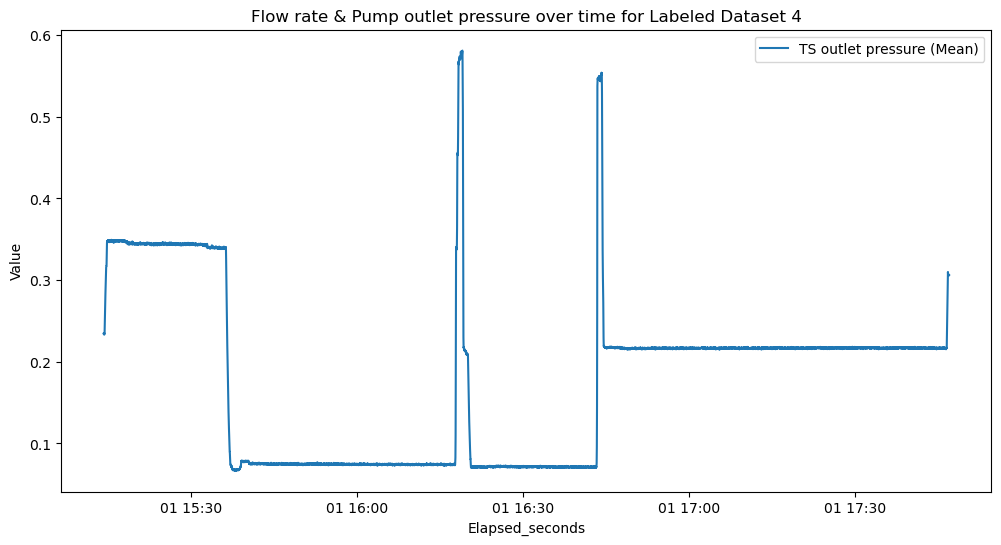

In [23]:
dv.visualize_key_column(dataset4, key="TS outlet pressure (Mean)", name="Labeled Dataset 4")

In [24]:
# check for big values
print("Max values in dataset4:\n", dataset4.max())
print("Min values in dataset4:\n", dataset4.min())
print(dataset4.info())

Max values in dataset4:
 Temperature TS outlet (Mean)    21.544143
Temperature TS inlet (Mean)      0.457931
Bypass temperature (Mean)       25.229397
Tank temperature (Mean)         -1.477327
TS outlet pressure (Mean)        0.581027
TS inlet pressure (Mean)         0.638479
Pump outlet pressure (Mean)      1.202929
Flow rate (Mean)                 1.452743
flow_rate_missing                1.000000
Plug                             0.000000
Plug_future                      0.000000
dtype: float64
Min values in dataset4:
 Temperature TS outlet (Mean)    20.875760
Temperature TS inlet (Mean)     -7.704643
Bypass temperature (Mean)       21.725973
Tank temperature (Mean)         -7.887004
TS outlet pressure (Mean)        0.066717
TS inlet pressure (Mean)         0.066913
Pump outlet pressure (Mean)      0.124967
Flow rate (Mean)                 0.038301
flow_rate_missing                1.000000
Plug                             0.000000
Plug_future                      0.000000
dtype: floa

In [25]:
def contains_infinite_or_big_values(df, threshold=1e6):
    '''Check if DataFrame contains infinite or very large values'''
    if np.isinf(df.select_dtypes(include=['number'])).values.any():
        return True
    if (df.select_dtypes(include=['number']).abs() > threshold).values.any():
        return True
    return False


In [26]:
dataset4.describe(include='all')

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),flow_rate_missing,Plug,Plug_future
count,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.0,9178.0,9178.0
mean,21.380588,-1.849395,23.187966,-2.562591,0.179489,0.200539,0.340269,0.756685,1.0,0.0,0.0
std,0.091052,1.374509,0.379009,1.013022,0.104925,0.116925,0.203421,0.183523,0.0,0.0,0.0
min,20.875760,-7.704643,21.725973,-7.887004,0.066717,0.066913,0.124967,0.038301,1.0,0.0,0.0
25%,21.354372,-2.289451,23.118292,-2.638094,0.074225,0.073901,0.132944,0.632367,1.0,0.0,0.0
50%,21.398837,-1.970142,23.198467,-2.491095,0.216226,0.250576,0.414133,0.754952,1.0,0.0,0.0
75%,21.432965,-0.846343,23.294034,-2.020994,0.217219,0.273315,0.415754,0.877537,1.0,0.0,0.0
max,21.544143,0.457931,25.229397,-1.477327,0.581027,0.638479,1.202929,1.452743,1.0,0.0,0.0


In [27]:
contains_infinite_or_big_values(dataset4)

False

# Dataset 5
Plug at 70 mins

In [28]:
show_info(dataset5)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-08-21 11:07:40.450,0.652198,0.002561,0.216821,1197.850879,21.892479,-6.356868,-5.944637,-5.825225,0.244302,0.724920,0.213840,0.282836,0.018072,0.081870,0.004608,11.816486
2021-08-21 11:07:40.949,0.650550,0.002615,0.216269,1196.577000,21.904315,-6.356699,-5.943776,-5.804735,0.247066,0.757112,0.213078,0.283316,0.018405,0.080948,0.004419,11.061990
2021-08-21 11:07:41.453,0.651297,0.002800,0.215000,1192.332124,21.883107,-6.318099,-5.939004,-5.823056,0.254509,0.747501,0.219824,0.281944,0.018836,0.079520,0.004669,11.592692
2021-08-21 11:07:41.949,0.651998,0.002484,0.215635,1189.644134,21.905444,-6.318045,-5.936312,-5.803727,0.245705,0.761614,0.199970,0.279040,0.018200,0.080179,0.005180,11.194329
2021-08-21 11:07:42.453,0.656662,0.002737,0.219138,1189.778269,21.904721,-6.317839,-5.936660,-5.802740,0.244332,0.777832,0.206917,0.256907,0.018160,0.082592,0.004637,10.450238


In [29]:
# Find 70 minutes marker
start_time = dataset5.index.min()
marker_time = start_time + pd.Timedelta(minutes=70)
print(f"70 minutes marker timestamp: {marker_time}")

# set plug
dataset5['Plug'] = np.where(dataset5.index >= marker_time, 1, 0)
dp.create_future_target(dataset5)

70 minutes marker timestamp: 2021-08-21 12:17:40.450000


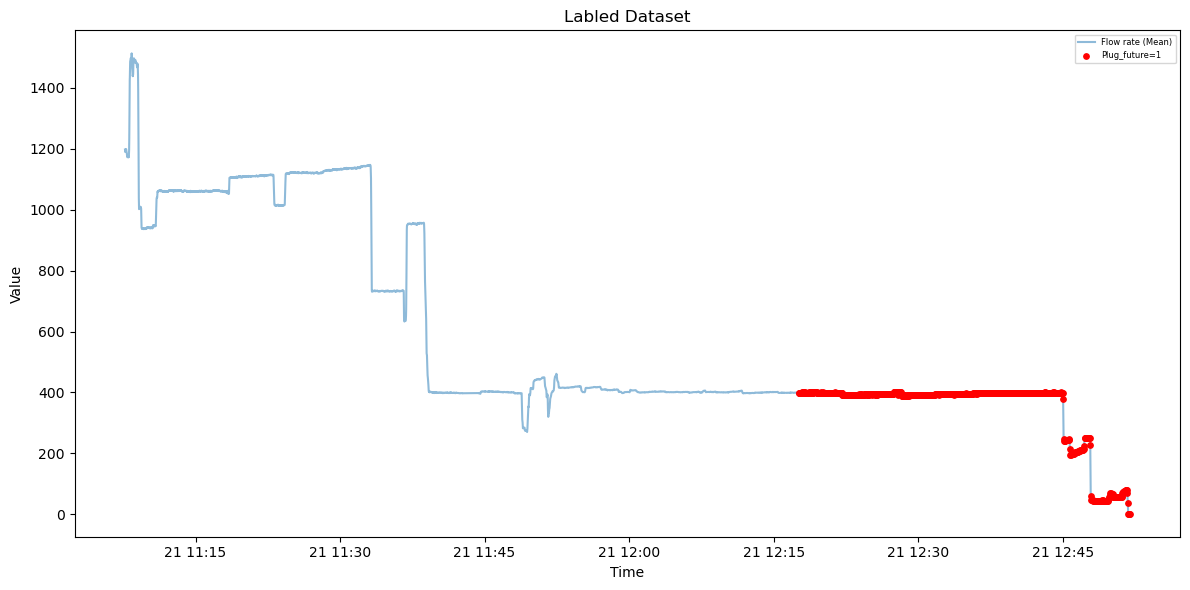

In [30]:
dv.visualize_plug_event(dataset5, plug_column="Plug_future", name="Labled Dataset")

# Dataset 6
No plug - manual adjustments

In [31]:
show_info(dataset6)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-09-23 11:44:15.469,-0.000953,0.000388,-0.002267,0.751986,22.254471,23.476945,22.523866,23.597269,0.204264,0.149411,0.118877,0.198649,0.013532,0.004897,0.005212,3.493279
2021-09-23 11:44:15.973,-0.000864,0.000299,-0.002195,0.701742,22.275812,23.469334,22.524412,23.596239,0.177941,0.149632,0.125484,0.187145,0.013116,0.005382,0.005186,3.441039
2021-09-23 11:44:16.474,-0.000679,0.000365,-0.002517,0.576880,22.277582,23.477137,22.522801,23.594067,0.177954,0.144385,0.118495,0.207919,0.012904,0.005223,0.005290,3.247005
2021-09-23 11:44:16.970,-0.000762,0.000494,-0.002137,0.809020,22.254735,23.465830,22.521484,23.593299,0.201474,0.144347,0.118798,0.196353,0.014150,0.005094,0.005319,2.960882
2021-09-23 11:44:17.469,-0.000832,0.000511,-0.002550,0.612487,22.248877,23.471958,22.525223,23.593919,0.214081,0.154330,0.122937,0.168015,0.014046,0.004871,0.005322,3.166494


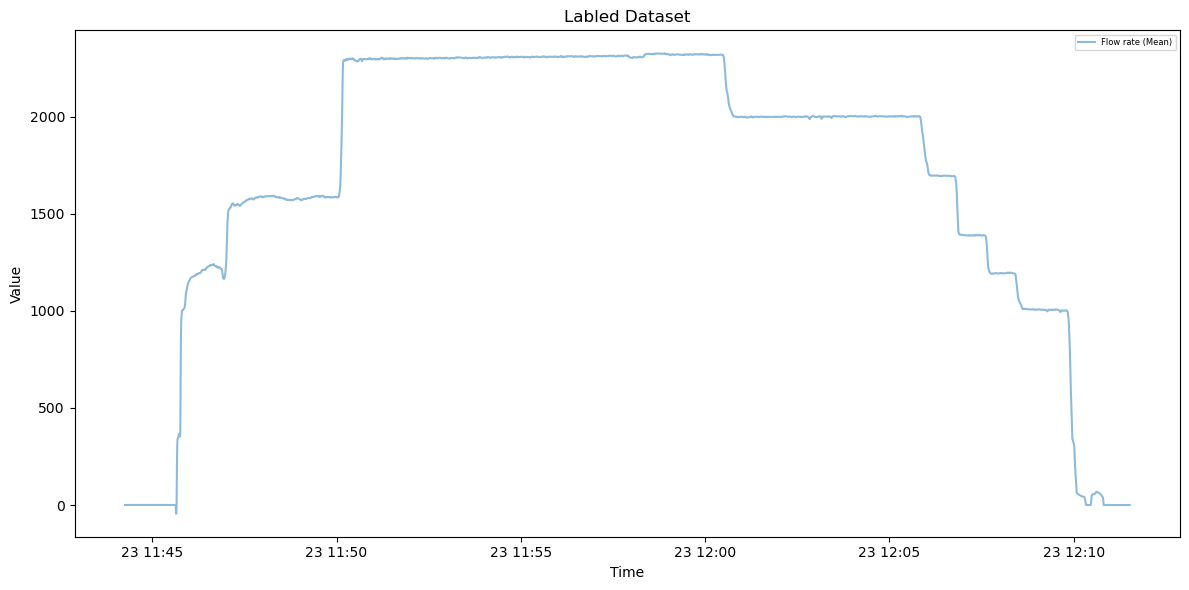

In [32]:
set_no_plug(dataset6)
dv.visualize_plug_event(dataset6, plug_column="Plug_future", name="Labled Dataset")

# Dataset 7
No plug

In [33]:
show_info(dataset7)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 11:05:25.279,-4.685960,-4.767171,24.552289,-4.856727,0.638409,0.981819,1.100481,2002.167506
1900-01-01 11:05:26.279,-4.648682,-4.732914,24.528003,-4.837302,0.639438,0.983993,1.102310,2000.616334
1900-01-01 11:05:27.279,-4.679922,-4.736195,24.537323,-4.852527,0.641821,0.987001,1.105452,2000.390024
1900-01-01 11:05:28.279,-4.664958,-4.732389,24.538505,-4.827196,0.641307,0.986917,1.106306,2001.936481
1900-01-01 11:05:29.279,-4.651307,-4.724776,24.532991,-4.832052,0.640892,0.984943,1.103081,2001.144393


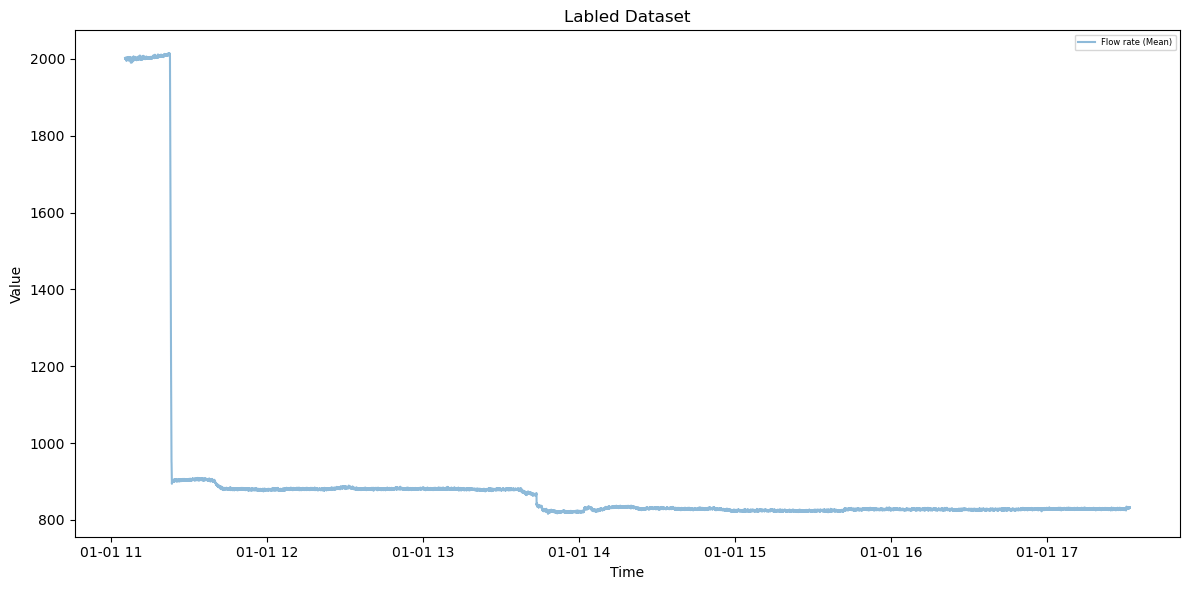

In [34]:
set_no_plug(dataset7)
dv.visualize_plug_event(dataset7, plug_column="Plug_future", name="Labled Dataset")

# Dataset 8
Loop block - 15:11:12-15:16:10  - first run
orifice block - 15:19:56-15:24:32 - second run

without flow rate measure?

In [35]:
show_info(dataset8)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 4
Duplicate index timestamps: 4
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:51:06.330,22.084809,23.496209,22.423823,22.306702,-0.001149,-0.000124,0.037587,1.127421
1900-01-01 14:51:07.330,22.086515,23.472452,22.425135,22.309064,-0.001296,-0.000103,0.037991,1.004836
1900-01-01 14:51:08.330,22.086122,23.481640,22.424741,22.308014,-0.001181,-0.000035,0.038083,0.948259
1900-01-01 14:51:09.330,22.088222,23.485972,22.425135,22.310245,-0.000960,0.000044,0.038221,1.103847
1900-01-01 14:51:10.330,22.084546,23.490697,22.424085,22.312214,-0.001223,0.000075,0.037973,1.094418


In [36]:
# cut out 
# 1500 - 1700 and 2000 - 2200 
dataset8 = cut(dataset8, 1500, 1700)
dataset8 = cut(dataset8, 2000, 2200)

In [37]:
# find first plug
start_time_first_plug = '15:11:12'
end_time_first_plug = '15:16:10'

start_time_second_plug = '15:19:56'
end_time_second_plug = '15:24:32'

set_plug_at_time(dataset8, start_time_first_plug, end_time_first_plug)
set_plug_at_time(dataset8, start_time_second_plug, end_time_second_plug)
dp.create_future_target(dataset8)

In [38]:
cut_time = dataset8.index[0] + pd.Timedelta(seconds=1500)

first_dataset8 = dataset8[(dataset8.index < cut_time)]
second_dataset8 = dataset8[(dataset8.index > cut_time)]

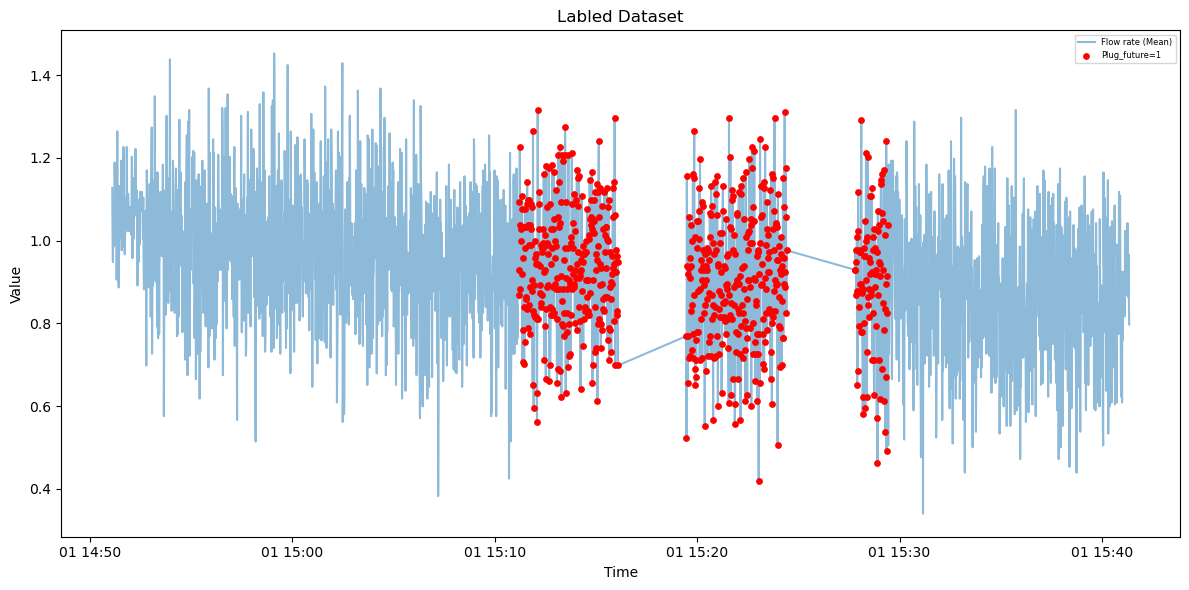

In [39]:
dv.visualize_plug_event(dataset8, plug_column="Plug_future", name="Labled Dataset")

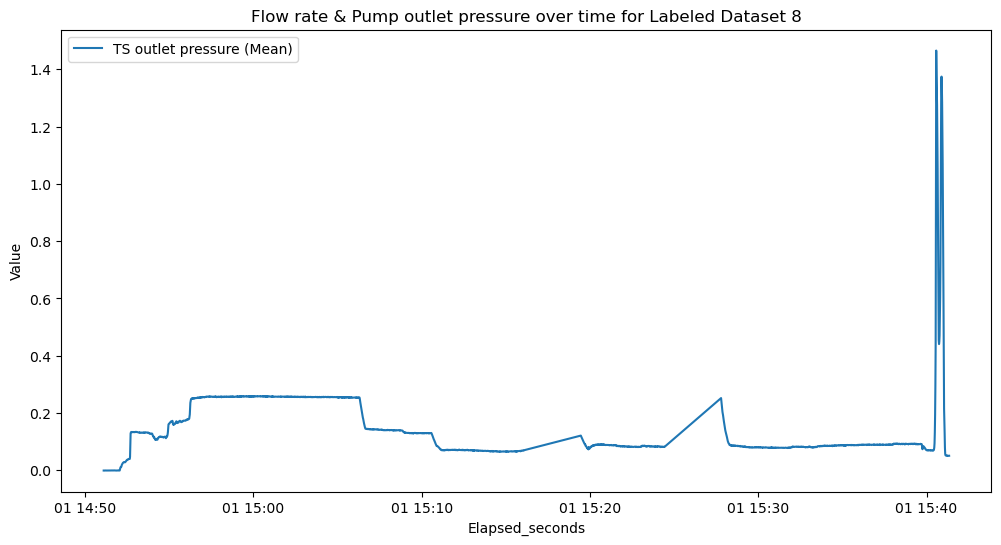

In [40]:
dv.visualize_key_column(dataset8, key="TS outlet pressure (Mean)", name="Labeled Dataset 8")

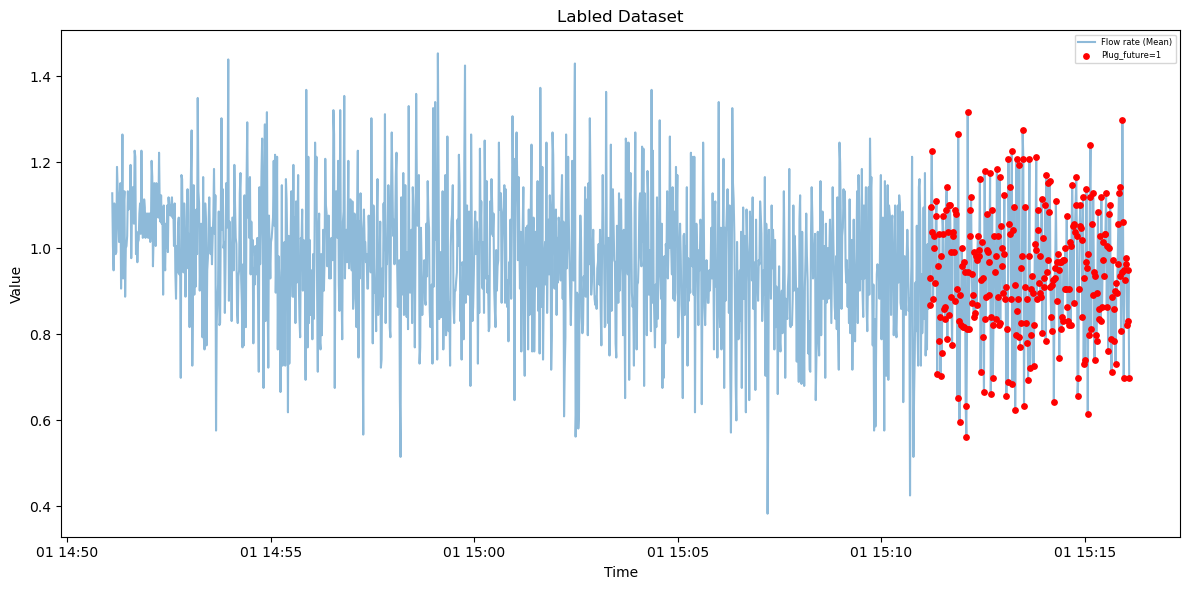

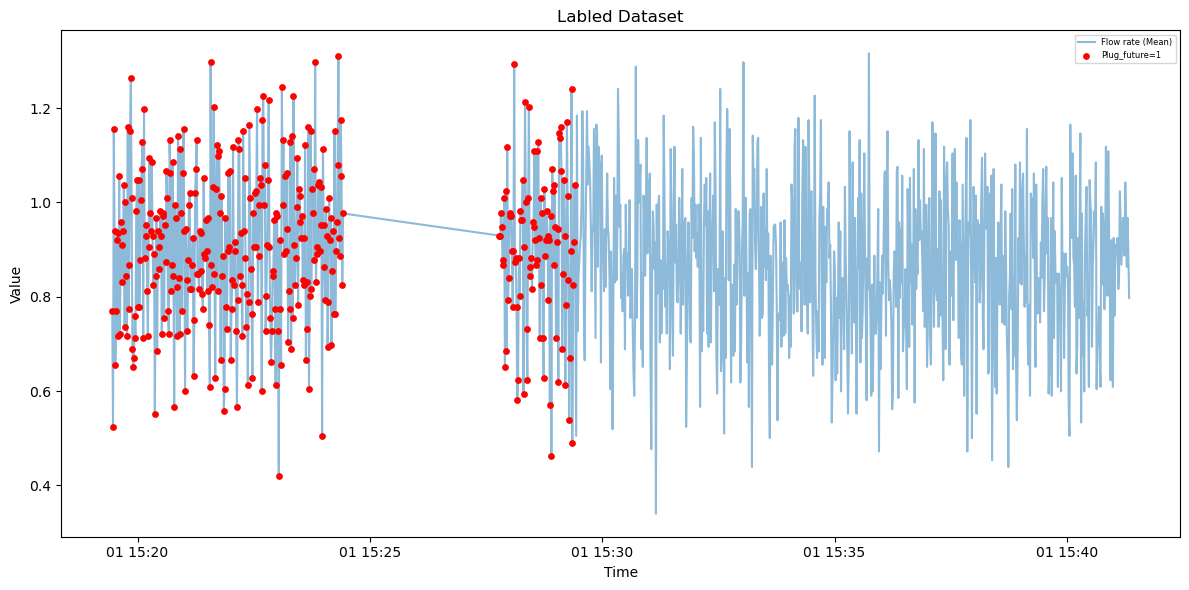

In [41]:
dv.visualize_plug_event(first_dataset8, plug_column="Plug_future", name="Labled Dataset")
dv.visualize_plug_event(second_dataset8, plug_column="Plug_future", name="Labled Dataset")

# Dataset 9
13:15:49-13:44:06 - test section block

without flow rate measure?

In [42]:
show_info(dataset9)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 12:50:22.552,22.105023,22.784024,22.143948,21.820424,-0.001144,0.001010,0.030614,0.962403
1900-01-01 12:50:23.552,22.103317,22.764467,22.139616,21.815305,-0.001050,0.001136,0.030568,1.070844
1900-01-01 12:50:24.552,22.107123,22.770242,22.134496,21.820030,-0.001286,0.001178,0.030586,1.136851
1900-01-01 12:50:25.552,22.105286,22.778642,22.133052,21.819111,-0.001212,0.001152,0.030779,1.150995
1900-01-01 12:50:26.552,22.104104,22.769192,22.133183,21.818061,-0.001223,0.000873,0.030467,1.188714


In [43]:
set_plug_at_time(dataset9, '13:15:49', '13:44:06')
dp.create_future_target(dataset9)

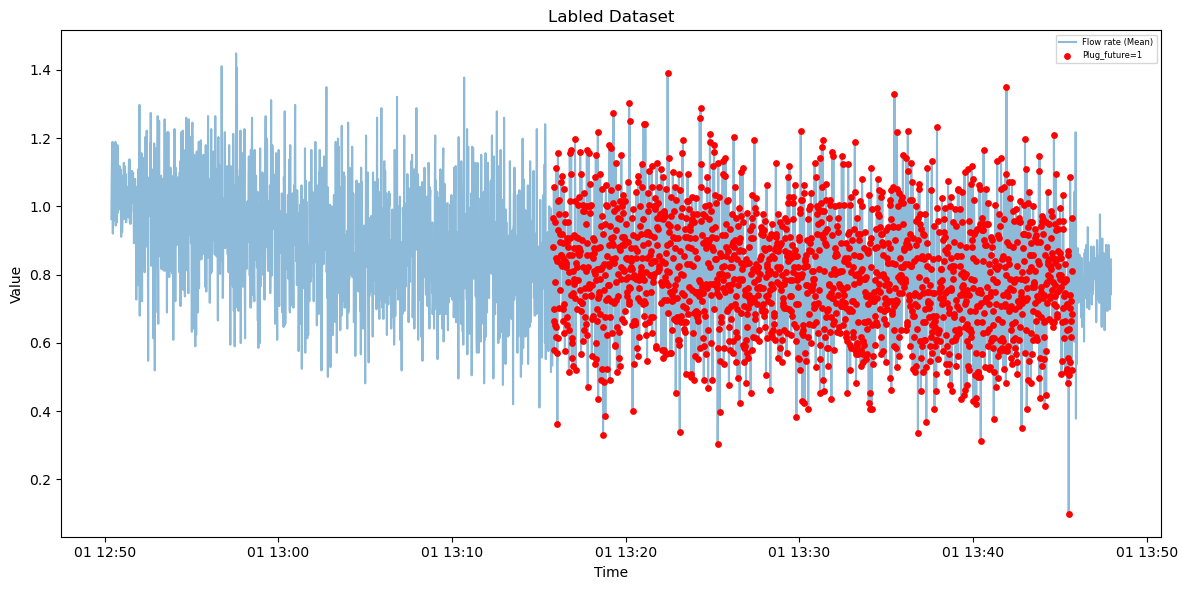

In [44]:
dv.visualize_plug_event(dataset9, plug_column="Plug_future", name="Labled Dataset")

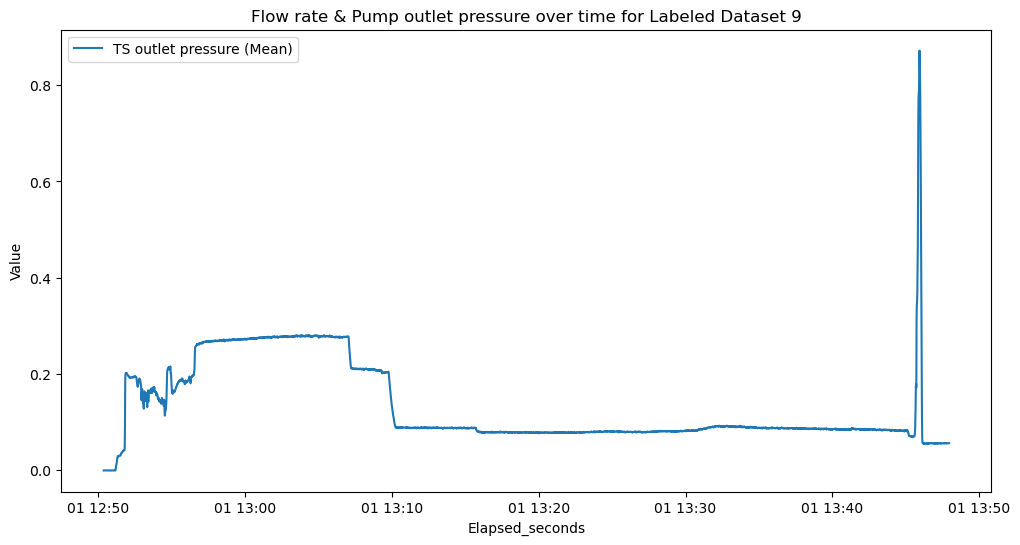

In [45]:
dv.visualize_key_column(dataset9, key="TS outlet pressure (Mean)", name="Labeled Dataset 9")

# Dataset 10
3 runs

13:57:15 - 13:59:21 -> Run 1 - loop blockage

14:01:48 - 14:06:57 -> Run 2 - orifice blockage

14:27:16 - 14:31:41 -> Run 3 - no block

without flow rate measure?

In [46]:
show_info(dataset10)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:55:39.663,21.999620,-2.009256,24.051350,-2.157328,0.354064,0.366056,0.646015,0.622937
1900-01-01 13:55:40.663,21.992532,-2.007550,24.048330,-2.145516,0.354553,0.366539,0.646474,1.042555
1900-01-01 13:55:41.663,21.996995,-2.005187,24.044261,-2.144203,0.354437,0.365835,0.645950,0.740807
1900-01-01 13:55:42.663,21.989644,-2.004662,24.046624,-2.144203,0.354327,0.365914,0.646400,1.165140
1900-01-01 13:55:43.663,21.976124,-2.009256,24.031921,-2.149060,0.354642,0.365273,0.646134,0.886966


In [47]:
set_plug_at_time(dataset10, '13:57:15', '13:59:21')
set_plug_at_time(dataset10, '14:01:48', '14:06:57')
dp.create_future_target(dataset10)

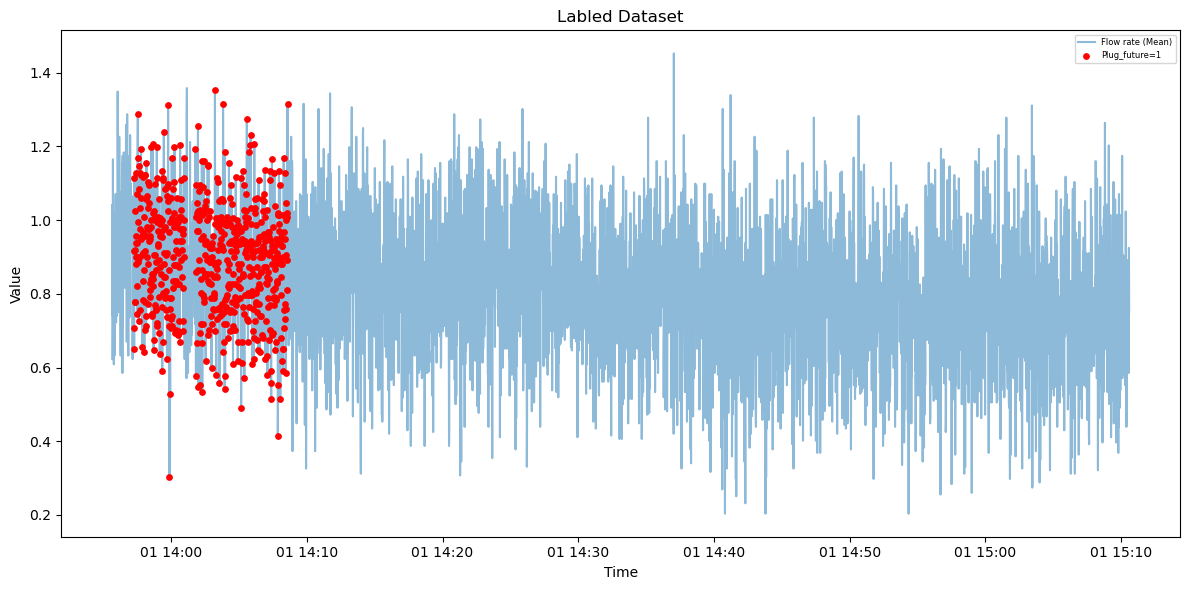

In [48]:
dv.visualize_plug_event(dataset10, plug_column="Plug_future", name="Labled Dataset")

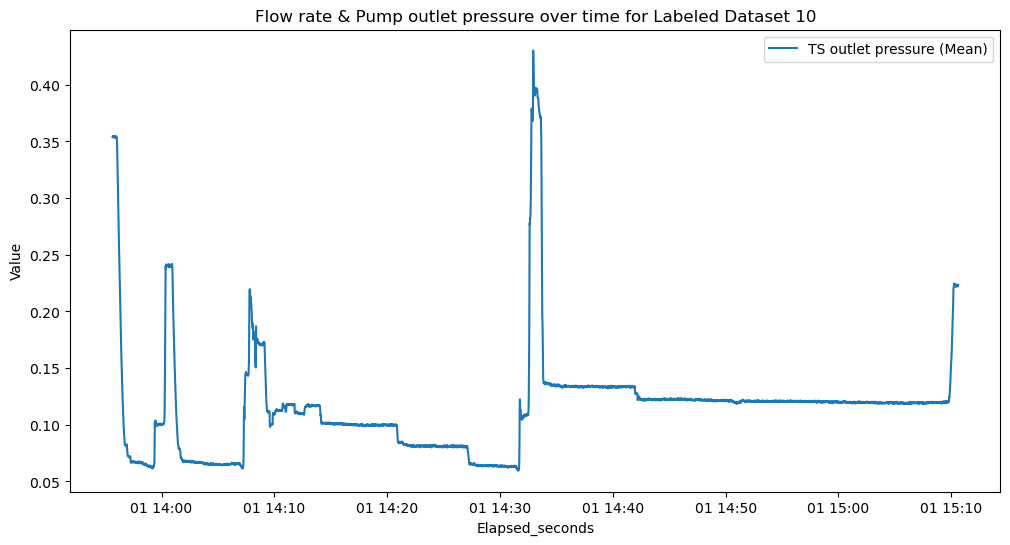

In [49]:
dv.visualize_key_column(dataset10, key="TS outlet pressure (Mean)", name="Labeled Dataset 10")

# Dataset 11

4 runs

Time of runs:

14:33:05 – 15:14:26 -> Run 1

15:20:20 – 15:28:59 -> Run 2 - block

15:33:24 – 15:44:06 -> Run 3 - block

15:49:03 - 16:08:07 -> Run 4 - block

without flow rate measure?

In [50]:
show_info(dataset11)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:56:49.628,21.208376,-6.971719,23.120621,-7.084154,0.251241,0.261635,0.463390,3.786573
1900-01-01 13:56:50.628,21.208376,-6.971456,23.122066,-7.081135,0.251745,0.262880,0.463335,3.720566
1900-01-01 13:56:51.628,21.223209,-6.960037,23.127054,-7.081267,0.251136,0.261336,0.462848,3.687562
1900-01-01 13:56:52.628,21.197350,-6.963318,23.122197,-7.075360,0.252407,0.262402,0.463518,3.711136
1900-01-01 13:56:53.628,21.198794,-6.957412,23.116027,-7.074573,0.252134,0.262449,0.463188,3.692277


In [51]:
set_plug_at_time(dataset11, '15:20:20', '15:28:59')
set_plug_at_time(dataset11, '15:33:24', '15:44:06')
set_plug_at_time(dataset11, '15:49:03', '16:08:07')
dp.create_future_target(dataset11)

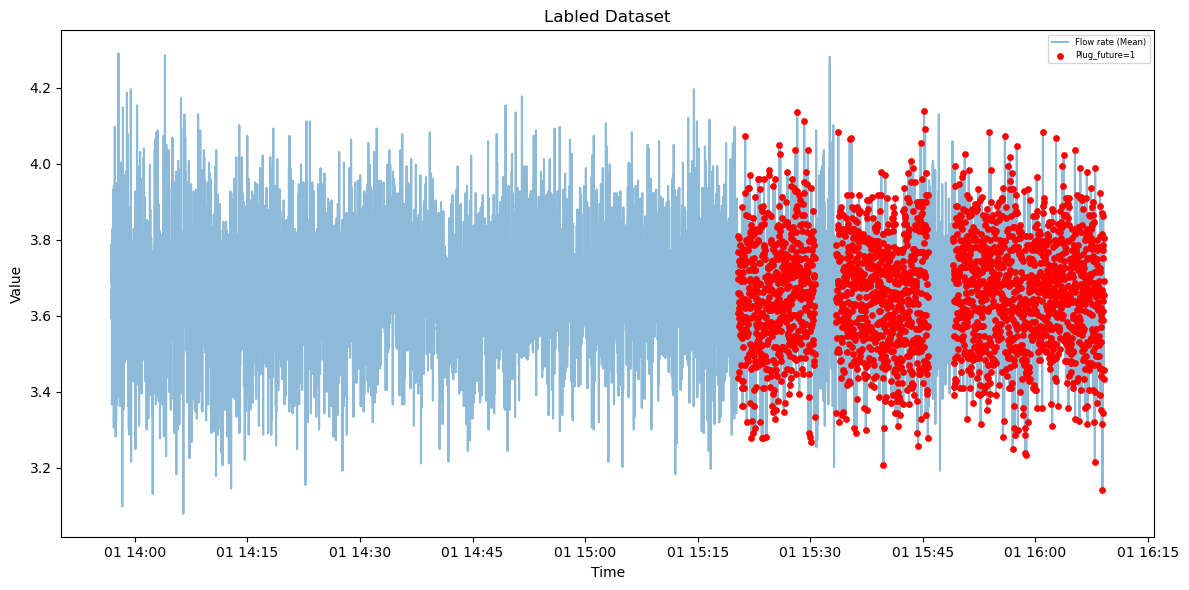

In [52]:
dv.visualize_plug_event(dataset11, plug_column="Plug_future", name="Labled Dataset")

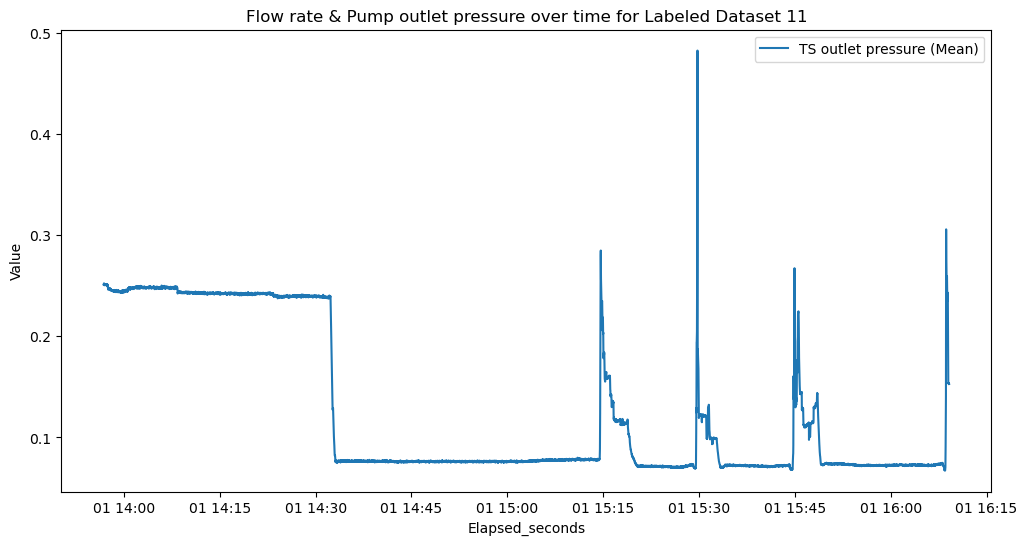

In [53]:
dv.visualize_key_column(dataset11, key="TS outlet pressure (Mean)", name="Labeled Dataset 11")

# Dataset 12
3 runs

Time-codes:

13:53:03 – 15:02:50

15:08:37 – 16:08:03

16:15:39 - 17:03:21 Loop blockage

without flow rate measure?

In [54]:
show_info(dataset12)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:35:02.939,21.251430,-5.328284,22.052975,-5.492760,0.255420,0.269122,0.475168,1.683769
1900-01-01 13:35:03.939,21.254187,-5.318308,22.060589,-5.488297,0.254701,0.268671,0.474984,1.415025
1900-01-01 13:35:04.939,21.252086,-5.320540,22.060195,-5.481210,0.255132,0.268225,0.475122,1.443314
1900-01-01 13:35:05.939,21.230953,-5.324215,22.058620,-5.481341,0.254554,0.268639,0.474617,1.396165
1900-01-01 13:35:06.939,21.234760,-5.317258,22.063477,-5.478191,0.256155,0.269616,0.475710,1.853502


In [55]:
set_plug_at_time(dataset12, '16:15:39', '17:03:21')
dp.create_future_target(dataset12)

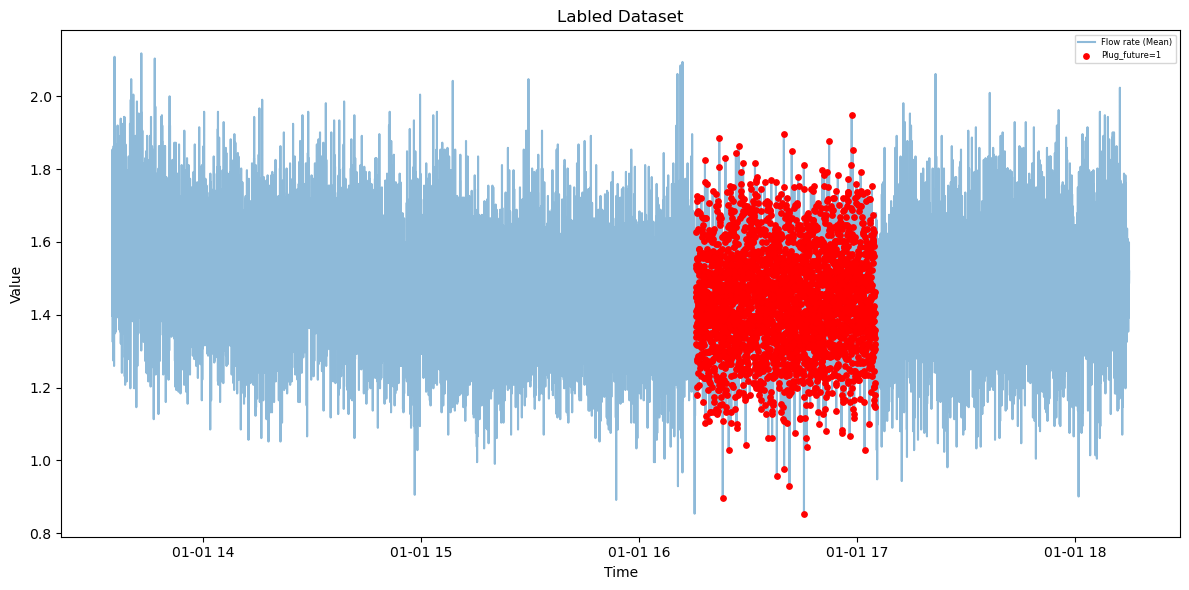

In [56]:
dv.visualize_plug_event(dataset12,   plug_column="Plug_future", name="Labled Dataset")

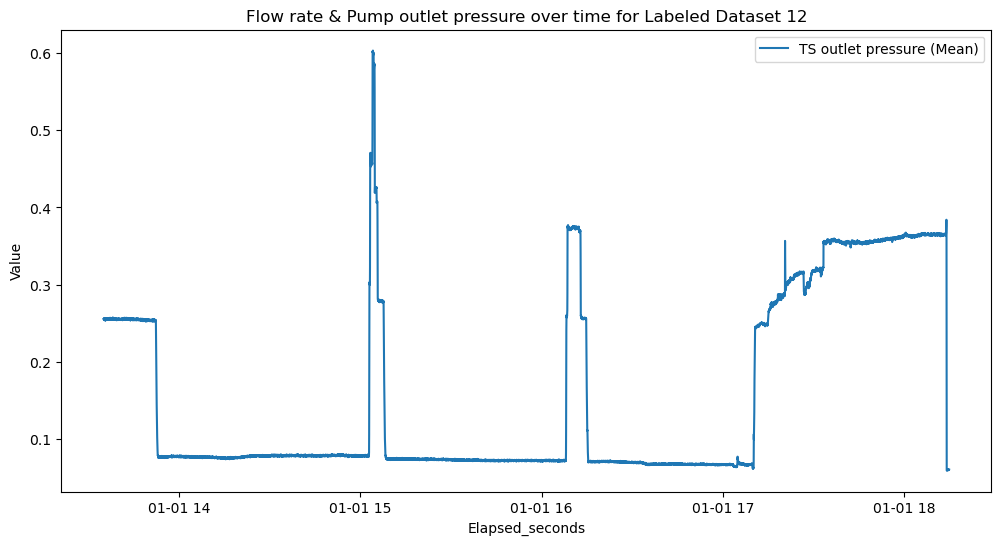

In [57]:
dv.visualize_key_column(dataset12, key="TS outlet pressure (Mean)", name="Labeled Dataset 12")

# Dataset 2
Under are the new datasets gotten from the second dataset.

# Dataset 13
> new data

Target flowrate: Differential pressure test

Pressure difference measured in the range 2000-800 kg/h
Orfice blockage at 600kg/h of pressure difference.


In [58]:
show_info(dataset13)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-10-01 09:24:54.672,0.000466,0.001626,-0.000470,1.132212,20.667575,23.683617,22.147018,22.637862,0.260384,0.256678,0.132427,0.751814,0.014425,0.006918,0.004982,4.738522
2021-10-01 09:24:55.176,-0.000332,0.001727,-0.000135,0.870128,20.739365,23.685747,22.165005,22.641643,0.257947,0.277226,0.125732,0.833738,0.013526,0.006416,0.004904,4.278510
2021-10-01 09:24:55.677,-0.000019,0.001423,-0.000757,0.906258,20.827817,23.710565,22.190586,22.640828,0.240683,0.244855,0.131860,0.825807,0.013855,0.007049,0.005110,4.579807
2021-10-01 09:24:56.176,0.000157,0.001500,-0.000507,1.349471,20.663894,23.668181,22.143539,22.639754,0.267119,0.270540,0.128743,0.762621,0.013506,0.007027,0.005022,4.683379
2021-10-01 09:24:56.672,-0.000646,0.001669,-0.000452,0.913582,20.778449,23.695525,22.177452,22.634156,0.252703,0.262686,0.122484,0.864748,0.013657,0.006340,0.005084,4.174759


In [59]:
#Set plug based on description
time = '2021-10-01 09:30:00.330000'

if 'Plug' not in dataset13.columns:
    dataset13['Plug'] = 0  
dataset13['Plug'] = np.where((dataset13.index >= time) & (dataset13["Flow rate (Mean)"] < 601), 1, dataset13['Plug'])

dp.create_future_target(dataset13)

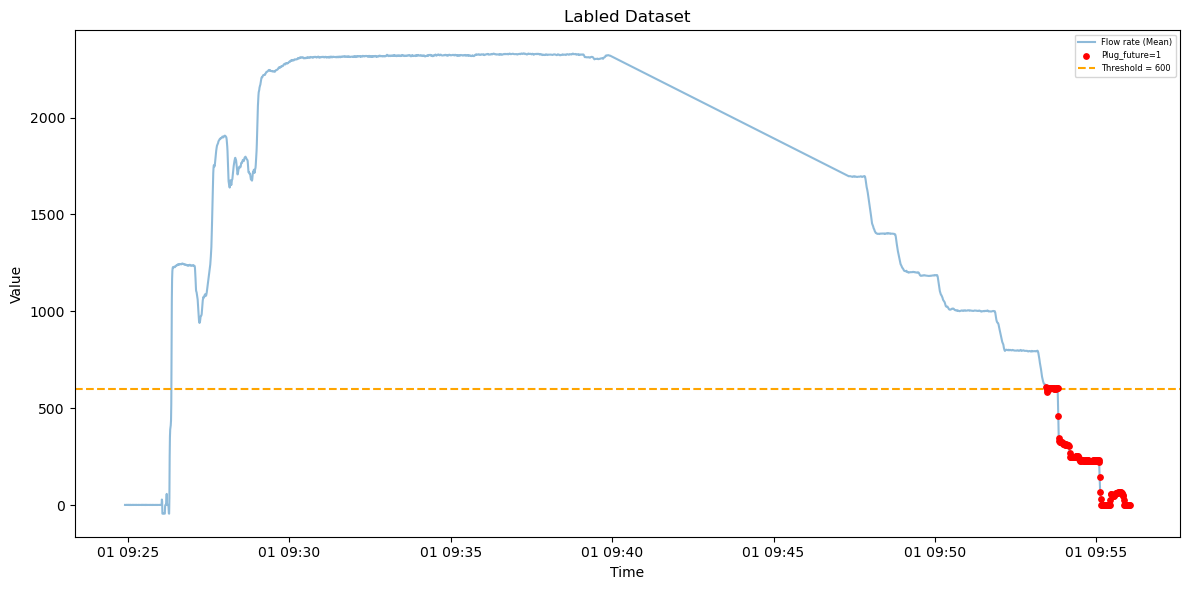

In [60]:
dv.visualize_plug_event(dataset13, plug_column="Plug_future", name="Labled Dataset", extra=True)

# Dataset 14

In [61]:
show_info(dataset14)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 11:28:48.233,-5.329010,-5.536322,22.401900,-5.742002,0.658827,0.980575,1.102227,1932.892828
1900-01-01 11:28:49.233,-5.319952,-5.533040,22.421328,-5.732158,0.659825,0.982407,1.105286,1932.906972
1900-01-01 11:28:50.233,-5.317459,-5.512696,22.388773,-5.722708,0.660072,0.982150,1.104478,1934.726888
1900-01-01 11:28:51.233,-5.300132,-5.488808,22.415684,-5.708796,0.660129,0.983825,1.105975,1934.736318
1900-01-01 11:28:52.233,-5.301576,-5.478963,22.368819,-5.704727,0.663437,0.986476,1.108961,1936.650530


In [62]:
set_no_plug(dataset14)

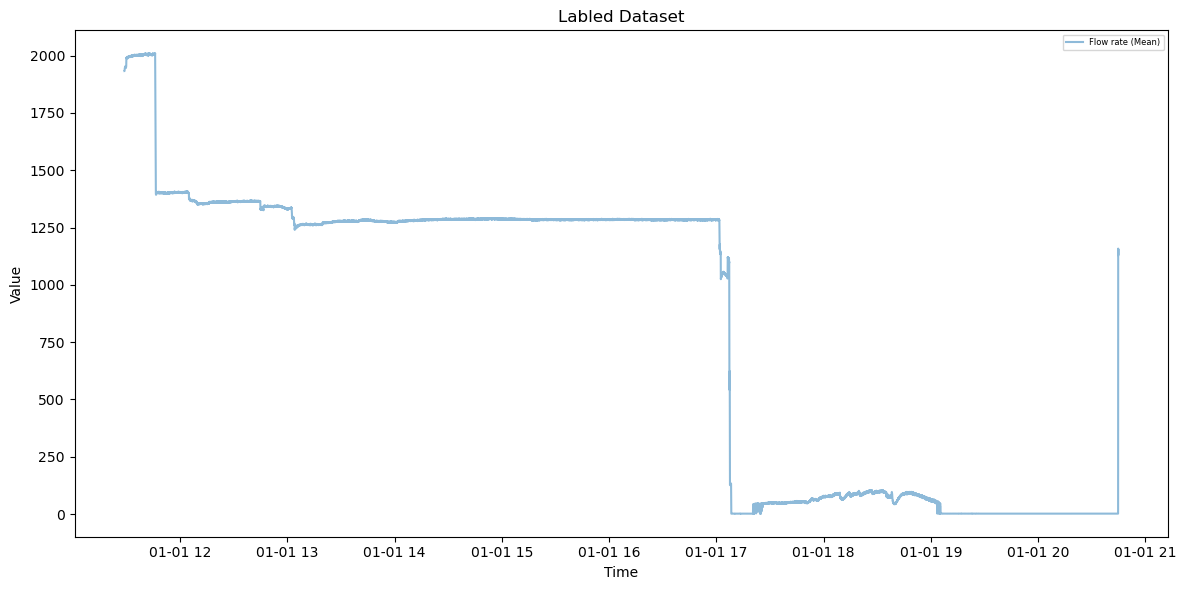

In [63]:
dv.visualize_plug_event(dataset14, plug_column="Plug_future", name="Labled Dataset")

# Dataset 15

13:42:38 – 13:47:05 – loop blockage

13:52:04 – 14:00:51 – test section plugging

14:07:56 – 14:15:36 – both loop and test section blocked

without flow rate measure?

In [64]:
show_info(dataset15)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:19:41.191,22.534248,23.763706,22.602354,22.486644,-0.001186,-0.000612,0.034693,0.971833
1900-01-01 13:19:42.191,22.532935,23.775519,22.594347,22.487431,-0.001170,-0.000502,0.034684,0.674800
1900-01-01 13:19:43.191,22.530310,23.775519,22.594478,22.488613,-0.001034,-0.000507,0.034170,0.872822
1900-01-01 13:19:44.191,22.536086,23.777487,22.593428,22.484413,-0.001134,-0.000523,0.034941,1.051984
1900-01-01 13:19:45.191,22.533329,23.812926,22.591196,22.485200,-0.000876,-0.000586,0.034399,0.802100


In [65]:
set_plug_at_time(dataset15, '13:42:38', '13:47:05')
set_plug_at_time(dataset15, '13:52:04', '14:00:51')
set_plug_at_time(dataset15, '14:07:56', '14:15:36')

dp.create_future_target(dataset15)

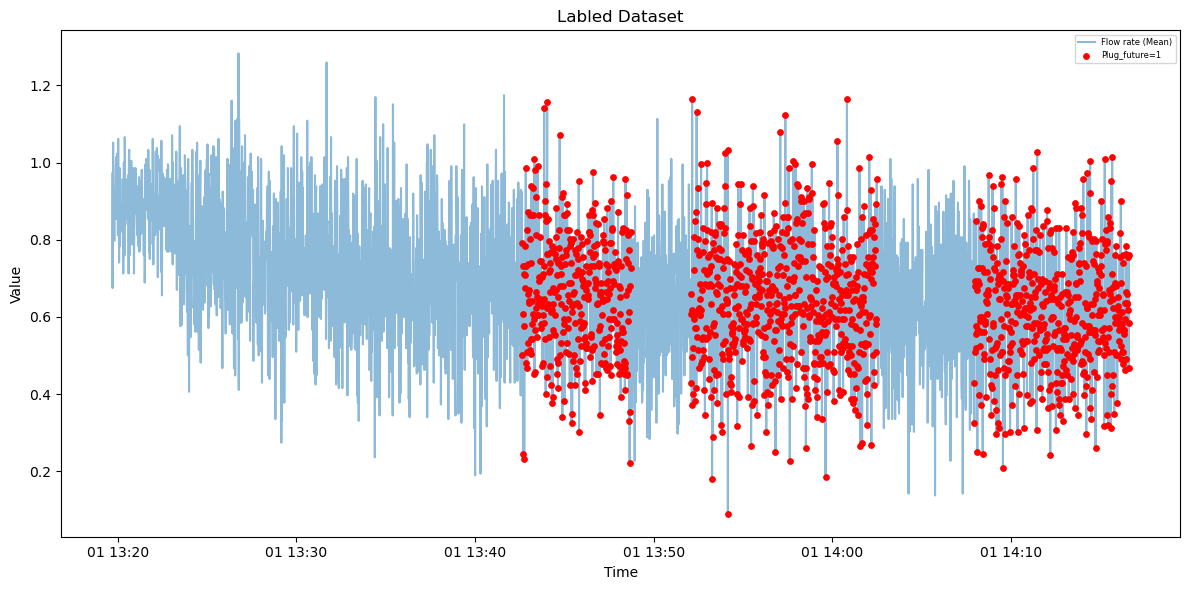

In [66]:
dv.visualize_plug_event(dataset15, plug_column="Plug_future", name="Labled Dataset")

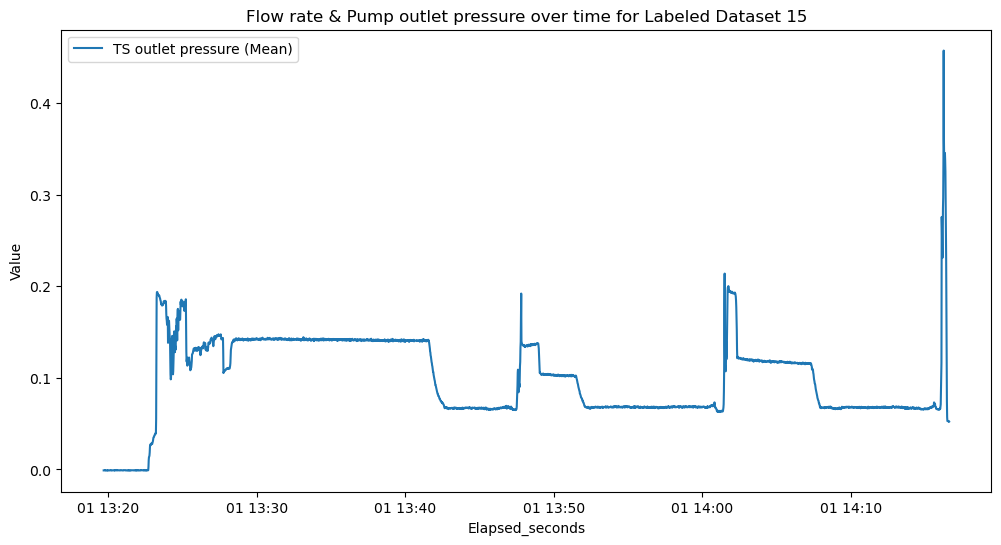

In [67]:
dv.visualize_key_column(dataset15, key="TS outlet pressure (Mean)", name="Labeled Dataset 15")

# Dataset 16

13:36:15 - 14:24:46

14:27:56 – 14:44:16

15:28:07 - 15:31:34

15:32:12 - 15:38:52

without flow rate measure?

In [68]:
show_info(dataset16)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:23:44.389,21.077509,-5.584623,21.649966,-5.392748,0.222044,0.232044,0.409332,1.132136
1900-01-01 13:23:45.389,21.051650,-5.560997,21.647866,-5.310324,0.222070,0.231508,0.408863,1.264151
1900-01-01 13:23:46.389,21.059788,-5.552335,21.644190,-5.275280,0.221944,0.231724,0.408643,1.235862
1900-01-01 13:23:47.389,21.064908,-5.536059,21.645109,-5.310849,0.221508,0.231262,0.408817,1.103847
1900-01-01 13:23:48.389,21.044825,-5.527134,21.636839,-5.280793,0.221409,0.232207,0.408468,1.183999


In [69]:
set_plug_at_time(dataset16, '13:36:15', '14:24:46')
set_plug_at_time(dataset16, '14:27:56', '14:44:16')
set_plug_at_time(dataset16, '15:28:07', '15:31:34')
set_plug_at_time(dataset16, '15:32:12', '15:38:52')

dp.create_future_target(dataset16)

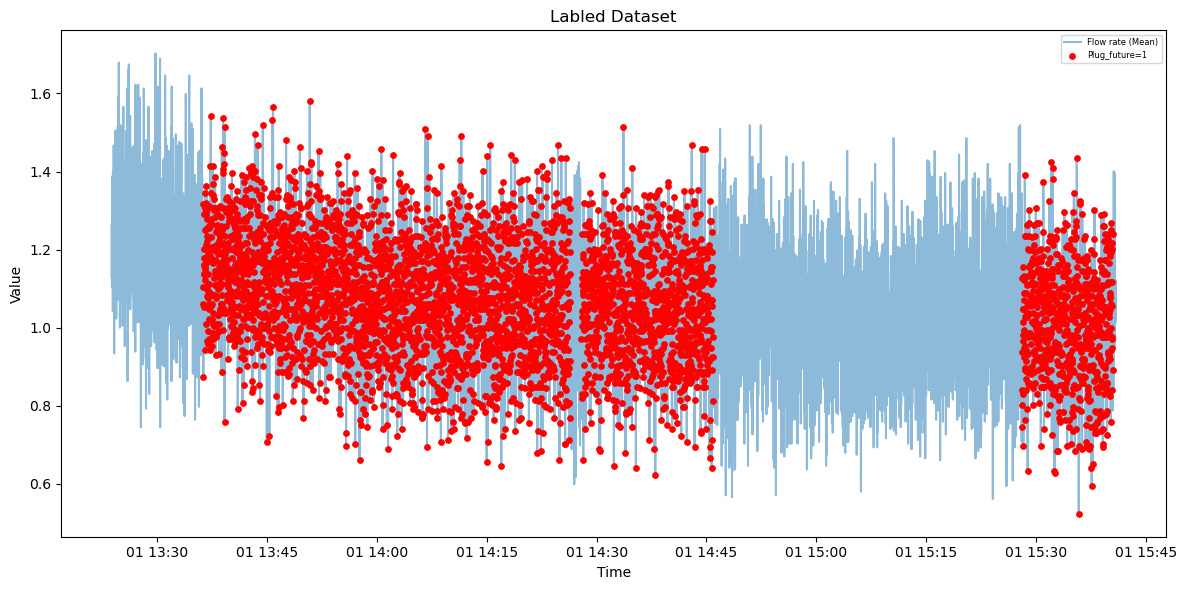

In [70]:
dv.visualize_plug_event(dataset16, plug_column="Plug_future", name="Labled Dataset")

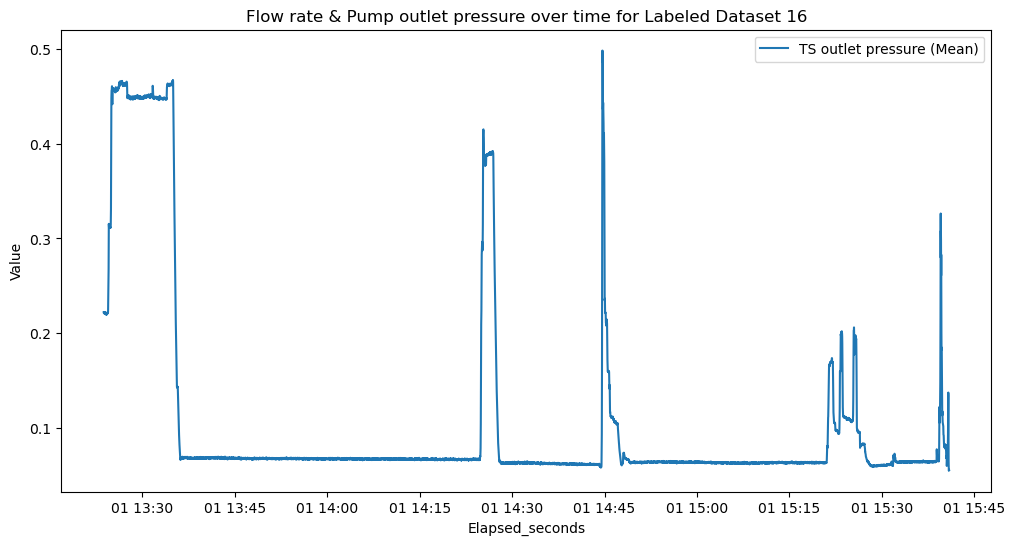

In [71]:
dv.visualize_key_column(dataset16, key="TS outlet pressure (Mean)", name="Labeled Dataset 16")

# Dataset 17

In [72]:
show_info(dataset17)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          object
Pump outlet pressure (Mean)        object
Differential pressure (Mean)       object
Flow rate (Mean)                   object
Tank temperature (Mean)            object
Temperature TS inlet (Mean)        object
Temperature TS outlet (Mean)       object
Bypass temperature (Mean)          object
Temperature TS outlet (Std Dev)    object
Temperature TS inlet (Std Dev)     object
Bypass temperatu

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-12-07 10:41:58.843,"0,000836","0,00404","0,004198","3,945888","22,829479","23,483296","22,442092","23,99797","0,480887","0,190923","0,158951","0,602606","0,015283","0,006433","0,00609","5,141446"
2021-12-07 10:41:59.347,"0,000678","0,004164","0,003821","3,994624","22,81435","23,483396","22,456698","23,998394","0,469358","0,199789","0,160407","0,615641","0,014805","0,006316","0,006175","4,974747"
2021-12-07 10:41:59.842,"0,000699","0,00386","0,004809","3,784292","22,806458","23,486736","22,436005","23,999029","0,445332","0,191802","0,152511","0,571008","0,014498","0,006044","0,006356","5,189717"
2021-12-07 10:42:00.347,"0,001043","0,004008","0,005425","3,826238","22,825808","23,508137","22,465292","23,993446","0,442021","0,180949","0,162811","0,588595","0,014552","0,006455","0,006161","5,272929"
2021-12-07 10:42:00.843,"0,001154","0,003563","0,005216","3,556156","22,814925","23,507112","22,440504","23,988442","0,419631","0,173093","0,163582","0,578803","0,013906","0,006272","0,006103","5,048219"


In [73]:
#Convert object to float
dataset17_object_cols = dataset17.select_dtypes(include=['object']).columns

dataset17[dataset17_object_cols] = (
    dataset17[dataset17_object_cols]
      .apply(lambda s: s.astype(str).str.strip())   
      .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})  
      .apply(lambda s: s.str.replace(",", ".", regex=False)) 
)

dataset17[dataset17_object_cols] = dataset17[dataset17_object_cols].apply(pd.to_numeric, errors="coerce")


In [74]:
show_info(dataset17)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-12-07 10:41:58.843,0.000836,0.004040,0.004198,3.945888,22.829479,23.483296,22.442092,23.997970,0.480887,0.190923,0.158951,0.602606,0.015283,0.006433,0.006090,5.141446
2021-12-07 10:41:59.347,0.000678,0.004164,0.003821,3.994624,22.814350,23.483396,22.456698,23.998394,0.469358,0.199789,0.160407,0.615641,0.014805,0.006316,0.006175,4.974747
2021-12-07 10:41:59.842,0.000699,0.003860,0.004809,3.784292,22.806458,23.486736,22.436005,23.999029,0.445332,0.191802,0.152511,0.571008,0.014498,0.006044,0.006356,5.189717
2021-12-07 10:42:00.347,0.001043,0.004008,0.005425,3.826238,22.825808,23.508137,22.465292,23.993446,0.442021,0.180949,0.162811,0.588595,0.014552,0.006455,0.006161,5.272929
2021-12-07 10:42:00.843,0.001154,0.003563,0.005216,3.556156,22.814925,23.507112,22.440504,23.988442,0.419631,0.173093,0.163582,0.578803,0.013906,0.006272,0.006103,5.048219


In [75]:
set_no_plug(dataset17)

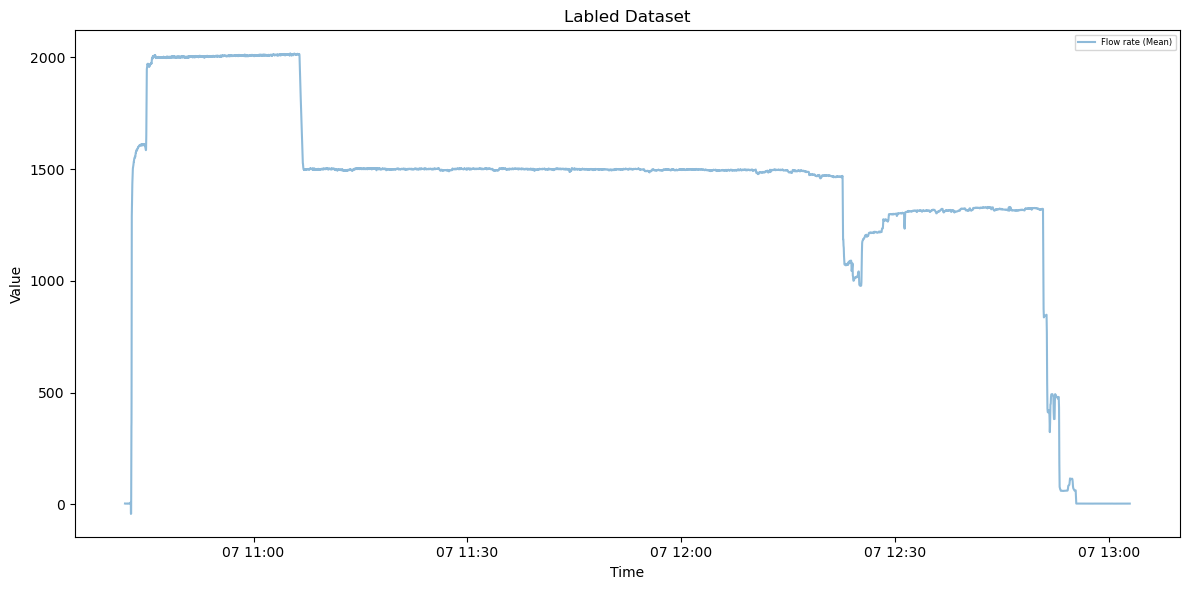

In [76]:
dv.visualize_plug_event(dataset17, plug_column="Plug_future", name="Labled Dataset")

# Dataset 18

Reconstructed the time column based on time sampling being 20hz, meaning a sample every 0.05 seconds, since the timestamp only provides a date.
This is done to enable visualization of the dataset.

In [77]:
show_info(dataset18)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 3
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
2022-11-03 14:06:00.000,-5.903935,-6.084833,25.778250,-6.030487,0.320851,0.457392,0.527352,1266.091633
2022-11-03 14:06:00.500,-5.879389,-6.059764,25.781270,-5.985469,0.320661,0.457439,0.527673,1265.290115
2022-11-03 14:06:01.000,-5.878995,-6.081158,25.784158,-6.040331,0.320803,0.456578,0.526598,1263.880387
2022-11-03 14:06:01.500,-5.868363,-6.078008,25.772737,-6.035868,0.321055,0.457754,0.527563,1263.861528
2022-11-03 14:06:02.000,-5.853530,-6.033644,25.771687,-5.994525,0.320714,0.457481,0.527600,1265.011941


In [78]:
set_no_plug(dataset18)

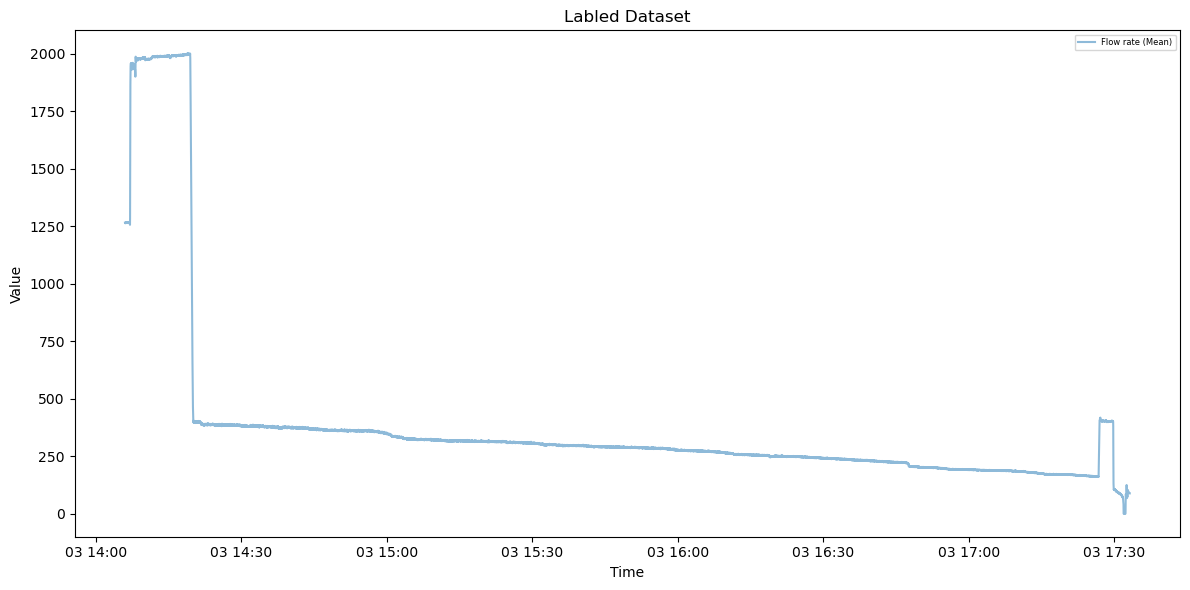

In [79]:
dv.visualize_plug_event(dataset18, plug_column="Plug_future", name="Labled Dataset")

# Dataset 19
The result of the test: Partial blockage during the test (1500 -> 1200 kg/h), then full blockage (1200 -> 500 -> 0 kg/h). The blockage of the test section



In [80]:
show_info(dataset19)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
TS outlet pressure (Mean)          float64
Pump outlet pressure (Mean)        float64
Differential pressure (Mean)       float64
Flow rate (Mean)                   float64
Tank temperature (Mean)            float64
Temperature TS inlet (Mean)        float64
Temperature TS outlet (Mean)       float64
Bypass temperature (Mean)          float64
Temperature TS outlet (Std Dev)    float64
Temperature TS inlet (Std Dev)     float64
Bypass

,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
2021-12-11 11:42:28.036,0.645331,0.993827,1.102425,1997.612909,-6.454473,-6.336605,-6.302838,24.558803,0.174138,0.184673,0.176160,0.747064,0.180930,0.019371,0.020451,8.499998
2021-12-11 11:42:28.186,0.654391,0.998200,1.099002,1996.586745,-6.433421,-6.352767,-6.296713,24.551545,0.200224,0.212430,0.184365,0.847224,0.184619,0.023051,0.023298,9.360806
2021-12-11 11:42:28.284,0.648390,0.996805,1.099284,1995.871505,-6.422225,-6.355303,-6.317571,24.547115,0.180322,0.204341,0.177747,0.873907,0.181793,0.022466,0.027068,8.948124
2021-12-11 11:42:28.385,0.653351,1.002438,1.102732,1995.626667,-6.420660,-6.343740,-6.287243,24.567341,0.210958,0.224363,0.180844,0.874649,0.172978,0.037186,0.035184,11.113790
2021-12-11 11:42:28.484,0.649936,0.995998,1.096682,1996.248612,-6.447766,-6.386283,-6.314771,24.514656,0.184075,0.174477,0.175234,0.826061,0.177204,0.020697,0.024504,10.054284


In [81]:
#Set plug based on description
if 'Plug' not in dataset19.columns:
    dataset19['Plug'] = 0  
dataset19['Plug'] = np.where((dataset19["Flow rate (Mean)"] < 1200), 1, dataset19['Plug'])

dp.create_future_target(dataset19)

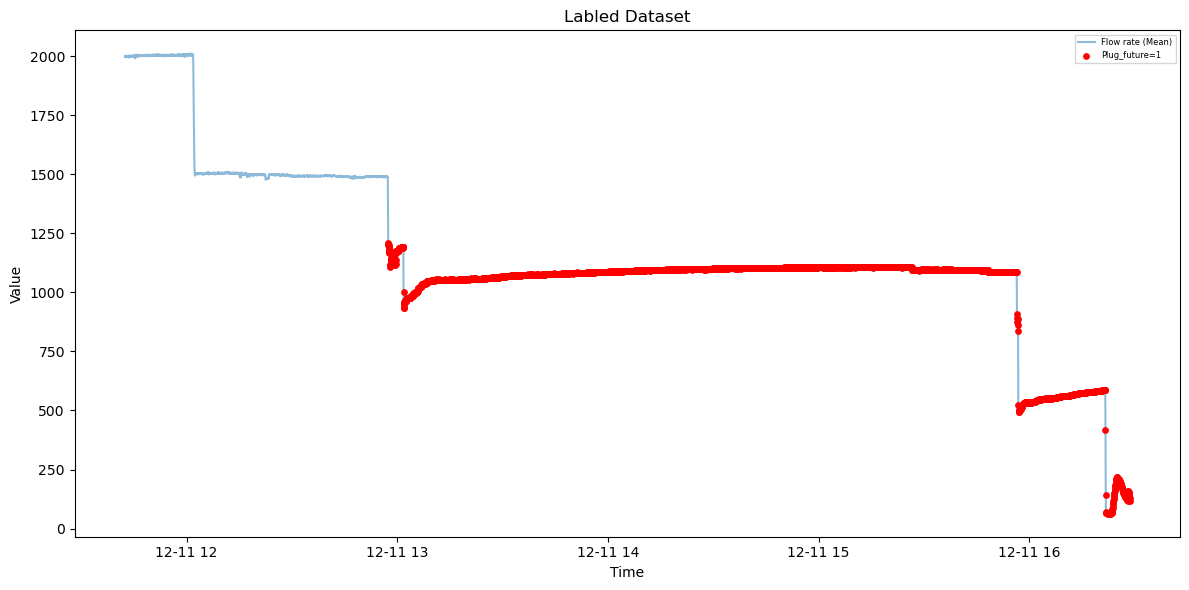

In [82]:
dv.visualize_plug_event(dataset19, plug_column="Plug_future", name="Labled Dataset")

# Dataset 20

14:36:10 – 14:39:59 – loop blocked (4.5 Hz)

14:52:49 - 15:05:17 – orifice blocked (5 Hz)

15:20:58 - 15:34:45 – loop blocked (5.5 Hz)

without flow rate measure?

In [83]:
show_info(dataset20)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:03:35.269,23.113373,2.418214,23.059317,-14.946758,0.131260,0.386811,0.491457,1.103847
1900-01-01 14:03:36.269,23.113767,1.926929,23.064962,-14.741091,0.131275,0.387535,0.492945,1.240577
1900-01-01 14:03:37.269,23.103791,1.527916,23.050915,-14.520461,0.131480,0.389346,0.494516,1.014266
1900-01-01 14:03:38.269,23.109173,1.215399,23.054854,-14.290119,0.131559,0.388737,0.493956,0.835103
1900-01-01 14:03:39.269,23.112980,0.958535,23.060367,-14.090752,0.131233,0.388239,0.492330,0.811529


In [84]:
set_plug_at_time(dataset20, '14:36:10', '14:39:59')
set_plug_at_time(dataset20, '14:52:49', '15:05:17')
set_plug_at_time(dataset20, '15:20:58', '15:34:45')


dp.create_future_target(dataset20)

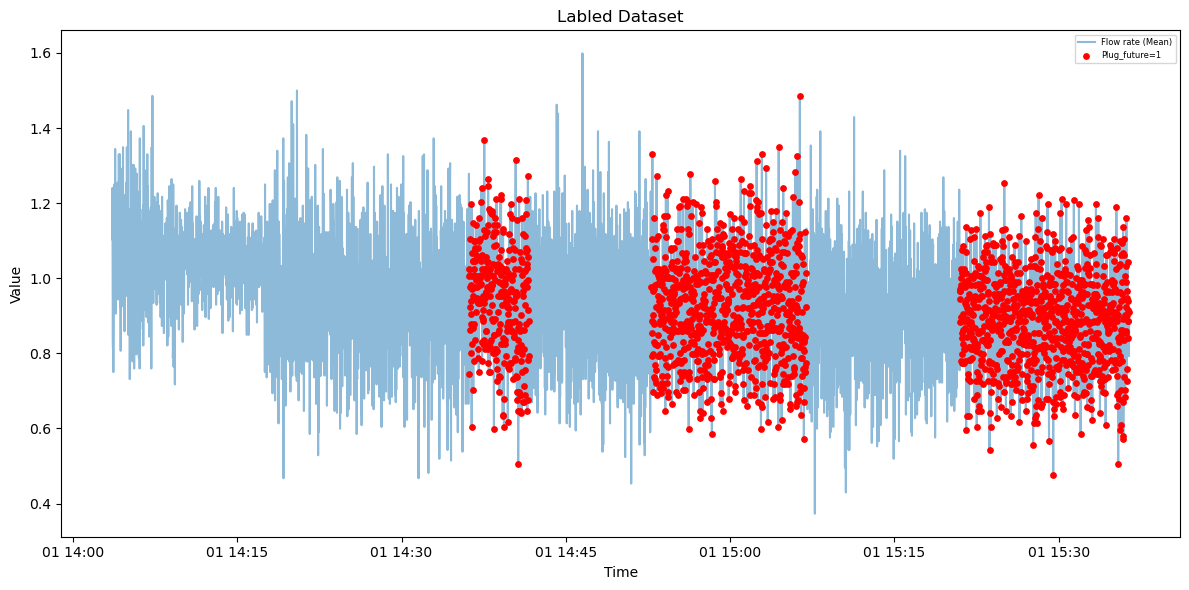

In [85]:
dv.visualize_plug_event(dataset20, plug_column="Plug_future", name="Labled Dataset")

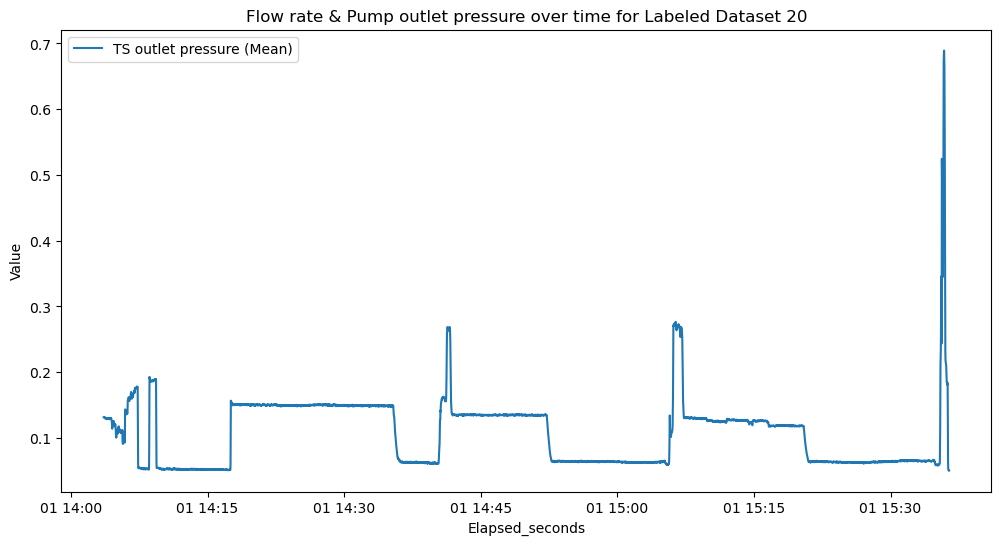

In [86]:
dv.visualize_key_column(dataset20, key="TS outlet pressure (Mean)", name="Labeled Dataset 20")

# Dataset 21

Time codes:

13:11:01 - 13:16:39 loop blocked

13:23:53 - 13:31:01 orifice blocked

13:45:42 - 14:06:44 loop blocked

14:13:36 - 14:36:09 loop blocked

without flow rate measure?

In [87]:
show_info(dataset21)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 12:53:07.659,21.091422,-8.236616,21.668344,-8.412000,0.392833,0.673924,0.990813,0.717233
1900-01-01 12:53:08.659,21.104680,-8.220866,21.676090,-8.400844,0.393705,0.673924,0.990372,1.141566
1900-01-01 12:53:09.659,21.096410,-8.209840,21.678452,-8.386276,0.393327,0.673719,0.990400,1.132136
1900-01-01 12:53:10.659,21.098511,-8.196977,21.681209,-8.374201,0.396382,0.677405,0.992981,1.254721
1900-01-01 12:53:11.659,21.148915,-8.168758,21.694468,-8.348082,0.394560,0.675547,0.992292,0.853963


In [88]:
set_plug_at_time(dataset21, '13:11:01', '13:16:39')
set_plug_at_time(dataset21, '13:23:53', '13:31:01')
set_plug_at_time(dataset21, '13:45:42', '14:06:44')
set_plug_at_time(dataset21, '14:13:36', '14:36:09')

dp.create_future_target(dataset21)

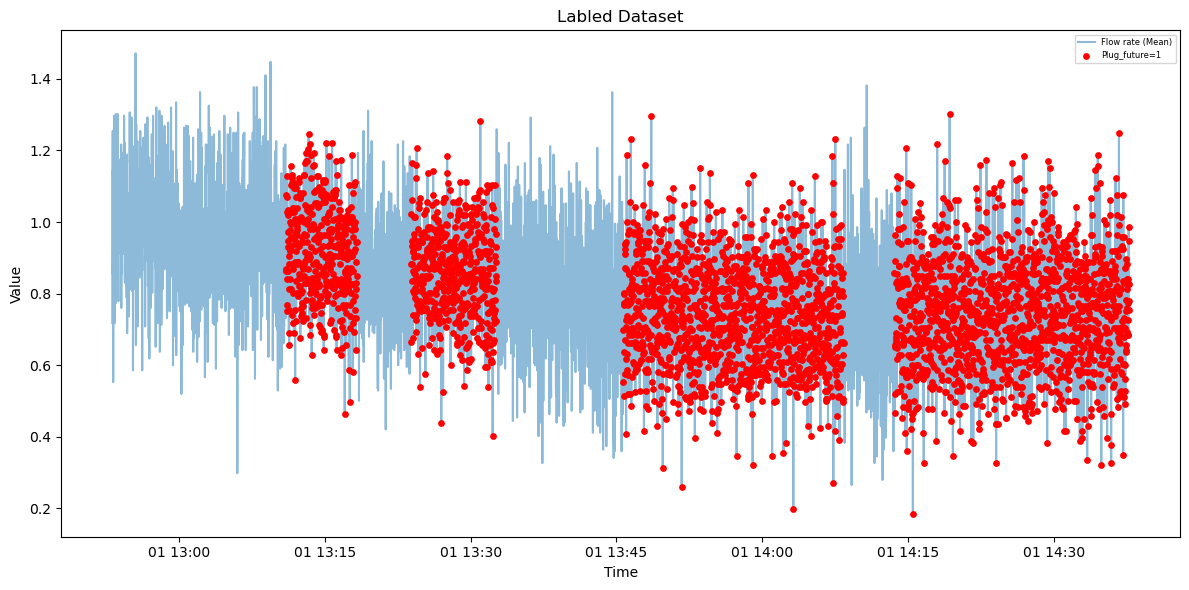

In [89]:
dv.visualize_plug_event(dataset21, plug_column="Plug_future", name="Labled Dataset")

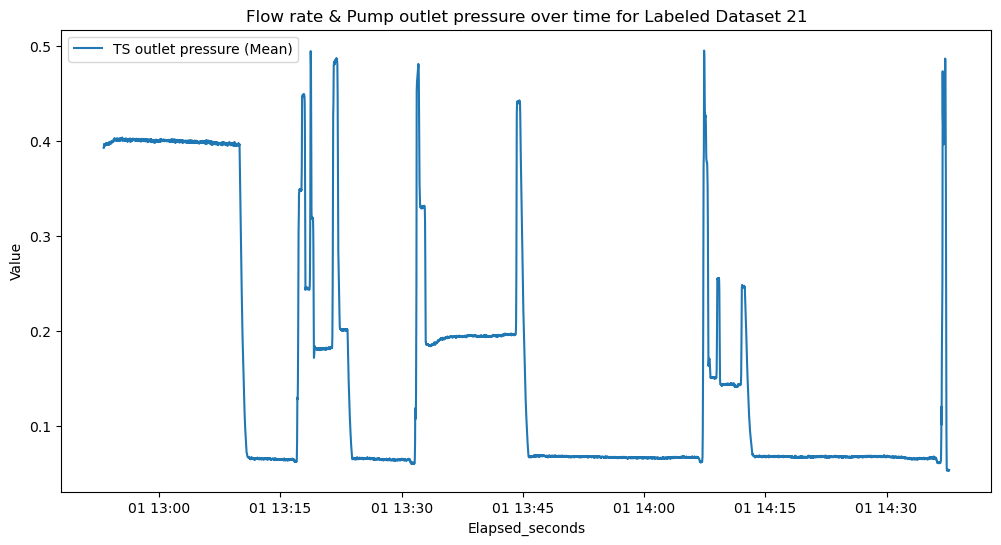

In [90]:
dv.visualize_key_column(dataset21, key="TS outlet pressure (Mean)", name="Labeled Dataset 21")

# Dataset 22
The test result: video started at 12:46:20. Loop blockage. Sedimentation at the top of the glass pipe, then covers the entire surface of the glass pipe. 


Reconstructed the time column based on time sampling being 20hz, meaning a sample every 0.05 seconds, since the timestamp only provides a date.
This is done to enable visualization of the dataset.
NB! the reconstructed time doesn´t comply with the description of the dataset, which states a 7.6% concentration changing at timestamp 13:04 which doesn´t exist with the reconstructed timeframe.

In [91]:
show_info(dataset22)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
2022-03-15 12:46:20.000,-5.526164,-5.578060,24.612937,-5.684383,0.650201,0.994709,1.111414,2002.341954
2022-03-15 12:46:20.500,-5.452789,-5.513615,24.586157,-5.642384,0.649503,0.993024,1.110633,2002.577695
2022-03-15 12:46:21.000,-5.457908,-5.523984,24.603748,-5.639234,0.651461,0.997712,1.114639,2001.568726
2022-03-15 12:46:21.500,-5.495318,-5.548791,24.588126,-5.686483,0.650789,0.995328,1.113399,2003.162331
2022-03-15 12:46:22.000,-5.508575,-5.554041,24.590752,-5.672177,0.650810,0.993433,1.111010,2004.364607


In [92]:
#find end timestamp
end = dataset22.index.max().strftime('%H:%M:%S')
print(f"End timestamp of dataset22: {end}")
set_plug_at_time(dataset22, '13:04:00', end, custom_date="2022-03-15")

dp.create_future_target(dataset22)

End timestamp of dataset22: 13:50:55


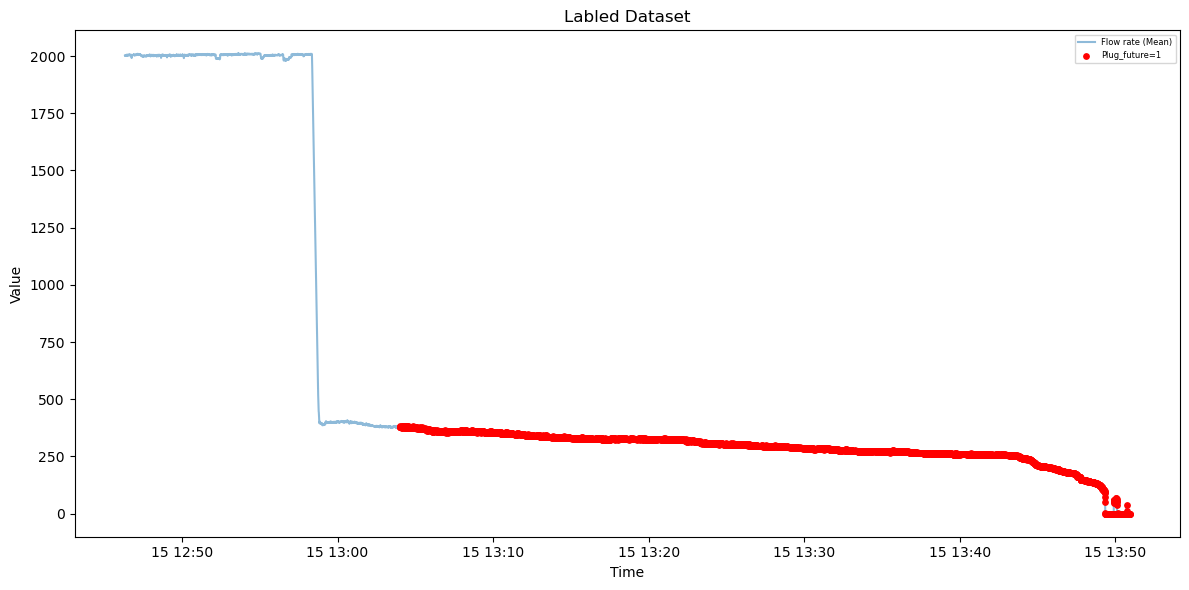

In [93]:
dv.visualize_plug_event(dataset22, plug_column="Plug_future", name="Labled Dataset")

# Dataset 23

13:40:14 – 13:50:30 - loop blockage

without flow rate measure?

In [94]:
show_info(dataset23)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:14:36.498,22.397605,23.126729,22.143160,22.241733,-0.000603,-0.000093,0.032626,1.051984
1900-01-01 13:14:37.498,22.397999,23.068189,22.143816,22.237533,-0.000609,-0.000014,0.032488,1.146281
1900-01-01 13:14:38.498,22.396161,23.059526,22.143029,22.231758,-0.000157,0.000343,0.032745,1.320729
1900-01-01 13:14:39.498,22.394980,23.102709,22.141454,22.230446,-0.000393,0.000301,0.032681,1.169855
1900-01-01 13:14:40.498,22.401149,23.121216,22.138697,22.236615,-0.000614,0.000096,0.032286,1.150995


In [95]:
set_plug_at_time(dataset23, '13:40:14', '13:50:30')

dp.create_future_target(dataset23)

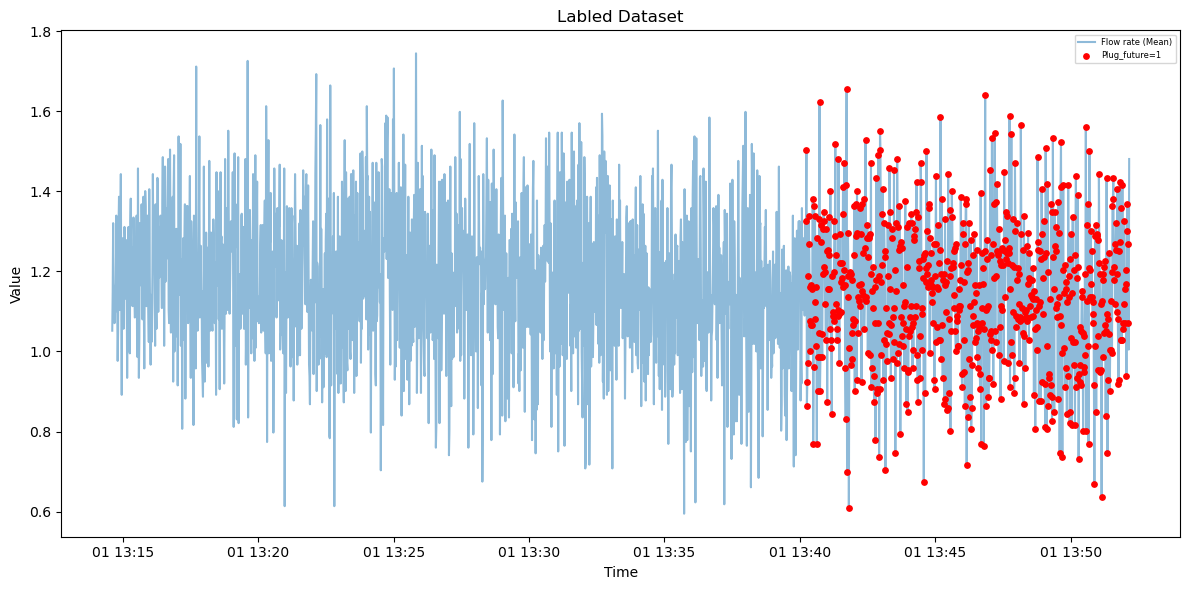

In [96]:
dv.visualize_plug_event(dataset23, plug_column="Plug_future", name="Labled Dataset")

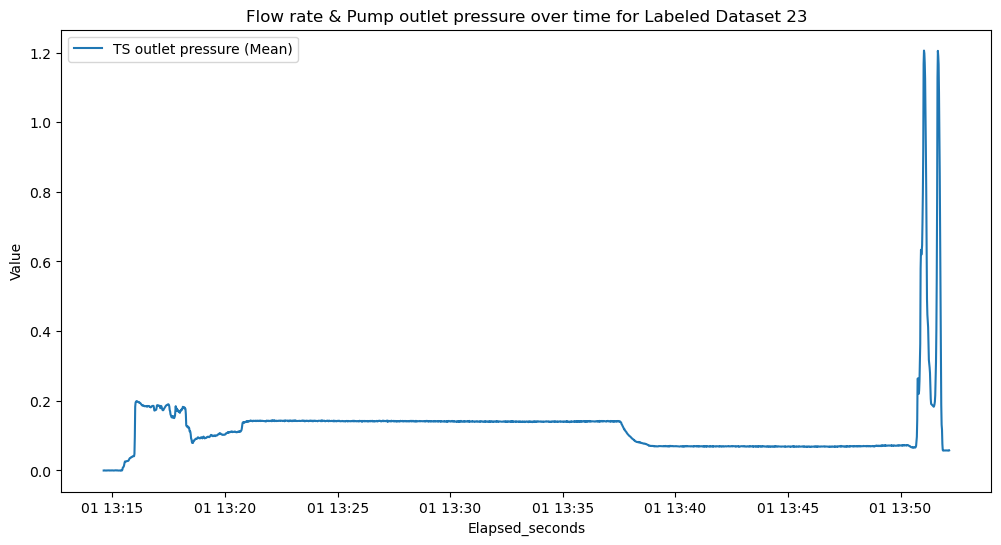

In [97]:
dv.visualize_key_column(dataset23, key="TS outlet pressure (Mean)", name="Labeled Dataset 23")

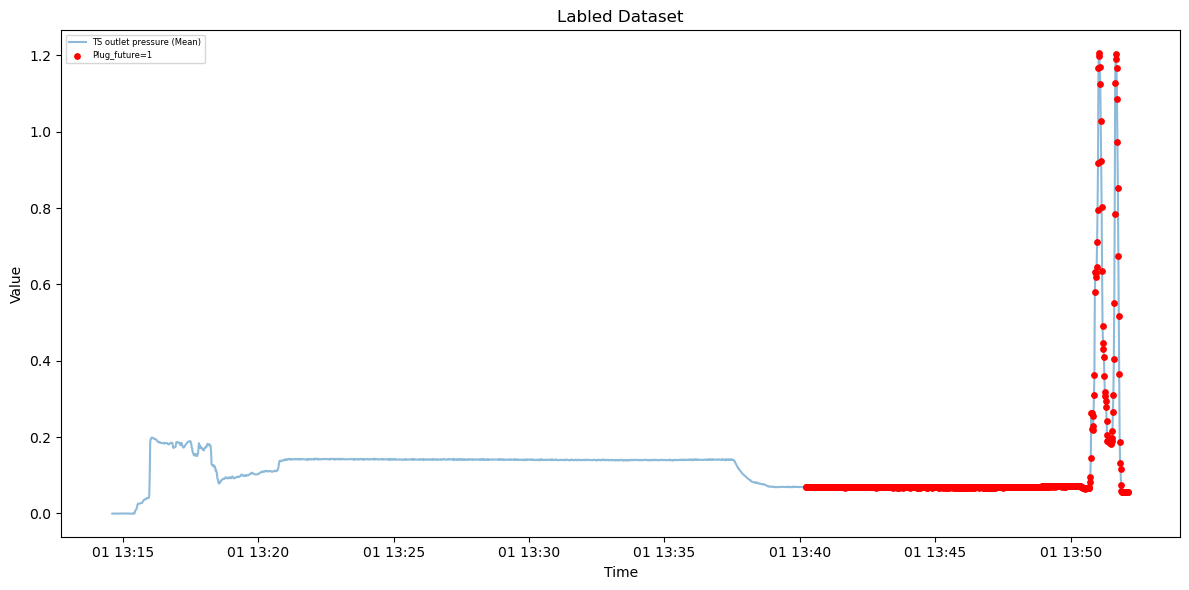

In [98]:
dv.visualize_plug_event(dataset23, plug_column="Plug_future", key="TS outlet pressure (Mean)", name="Labled Dataset")

# Dataset 24

In [99]:
show_info(dataset24)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:44:02.474,-5.801682,-5.979699,27.357731,-5.379098,0.666509,1.006186,1.127667,1979.130953
1900-01-01 13:44:03.474,-5.781993,-5.948854,27.350774,-5.360986,0.666650,1.006412,1.126739,1981.045165
1900-01-01 13:44:04.474,-5.777399,-5.936516,27.348148,-5.150725,0.666346,1.007273,1.127841,1982.770785
1900-01-01 13:44:05.474,-5.769260,-5.947410,27.353137,-5.214381,0.665821,1.006339,1.127758,1983.991920
1900-01-01 13:44:06.474,-5.756528,-5.933497,27.350511,-5.261105,0.666393,1.005845,1.127777,1984.048498


In [100]:
set_no_plug(dataset24)

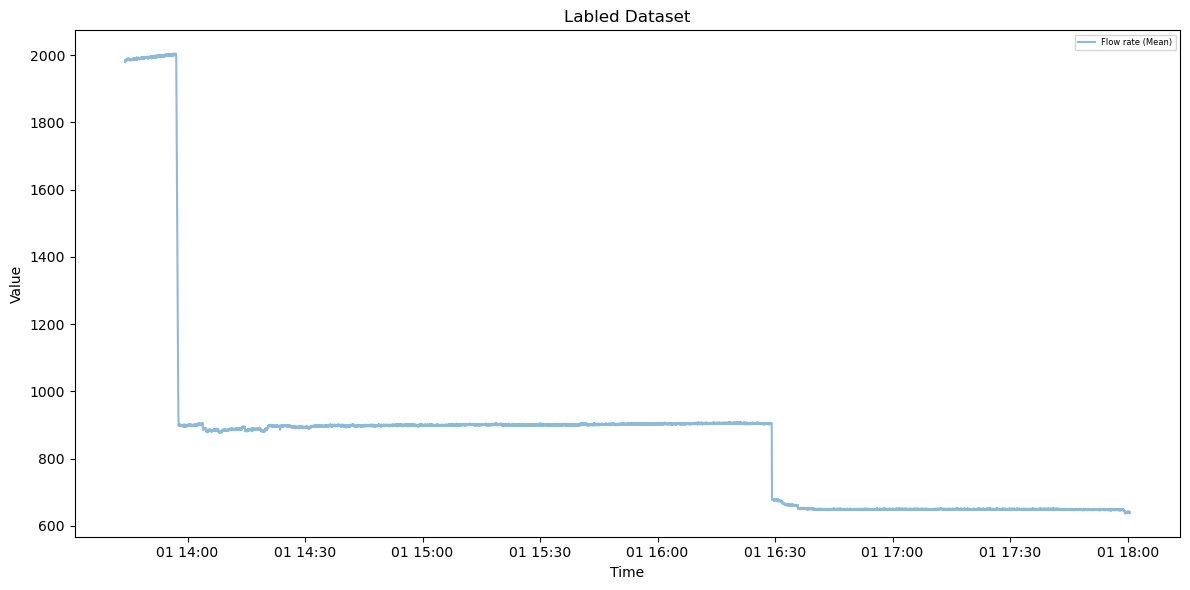

In [101]:
dv.visualize_plug_event(dataset24, plug_column="Plug_future", name="Labled Dataset")

# Dataset 25

14:25:56  –– 14:53:52 blockage of the orifice

without flow rate measure?


In [102]:
show_info(dataset25)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 8
Duplicate index timestamps: 8
Datatypes:
Temperature TS outlet (Mean)    float64
Temperature TS inlet (Mean)     float64
Bypass temperature (Mean)       float64
Tank temperature (Mean)         float64
TS outlet pressure (Mean)       float64
TS inlet pressure (Mean)        float64
Pump outlet pressure (Mean)     float64
Flow rate (Mean)                float64
dtype: object


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:00:53.654,22.477543,-6.878659,22.462023,-7.154766,0.181374,0.578041,0.730648,0.830388
1900-01-01 14:00:54.654,22.474655,-6.882334,22.461498,-7.148466,0.181689,0.579947,0.733055,1.212288
1900-01-01 14:00:55.654,22.470455,-6.879447,22.462942,-7.146104,0.181563,0.580330,0.733652,1.169855
1900-01-01 14:00:56.654,22.465861,-6.869603,22.461892,-7.120248,0.182015,0.583397,0.737676,1.349017
1900-01-01 14:00:57.654,22.480693,-6.853721,22.464649,-7.108435,0.182241,0.583701,0.737492,1.051984


In [103]:
set_plug_at_time(dataset25, '14:25:56', '14:53:52')

dp.create_future_target(dataset25)

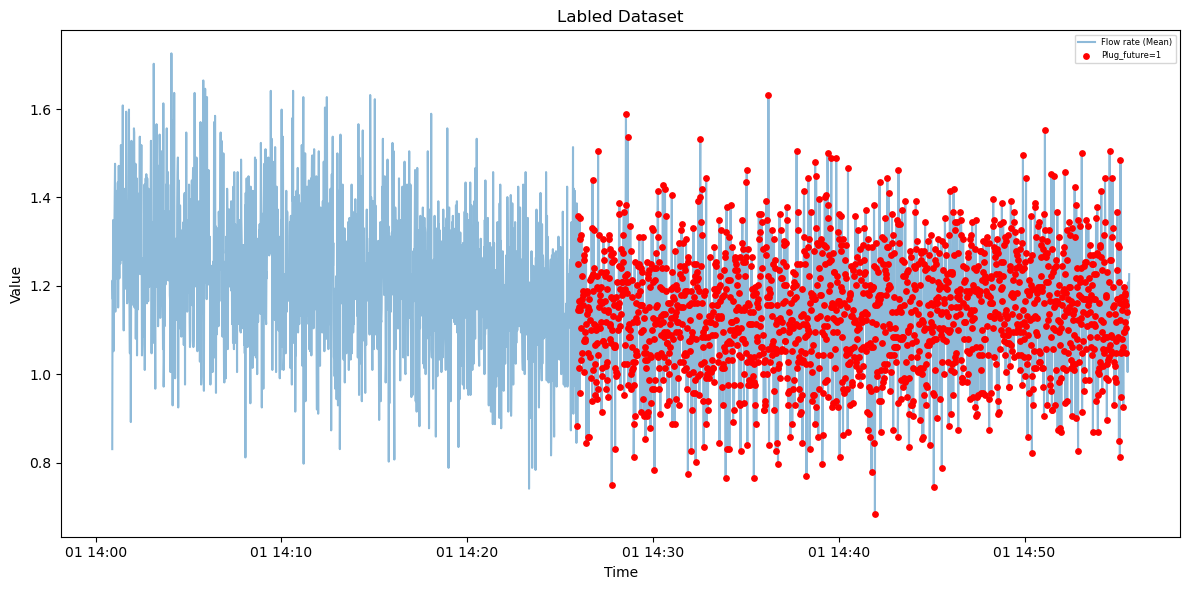

In [104]:
dv.visualize_plug_event(dataset25, plug_column="Plug_future", name="Labled Dataset")

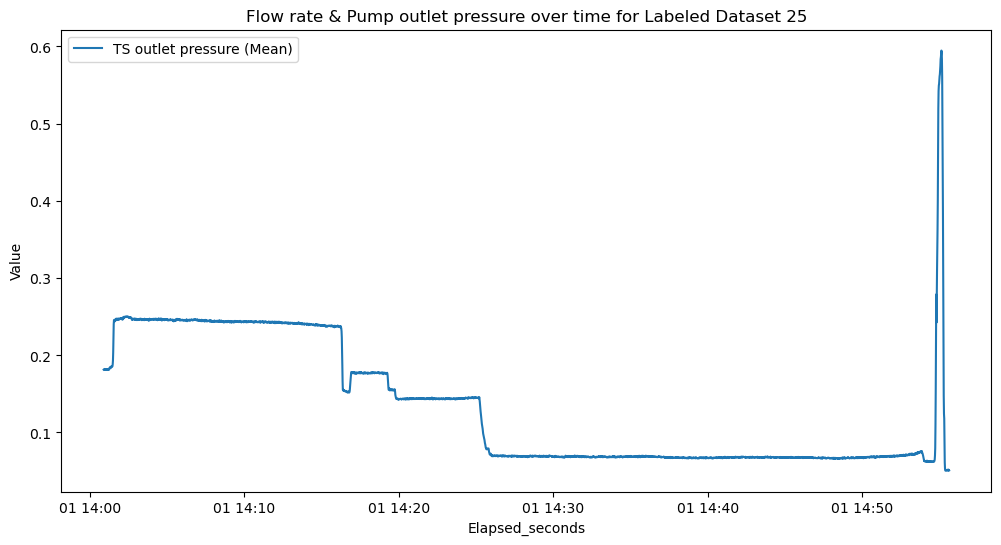

In [105]:
dv.visualize_key_column(dataset25, key="TS outlet pressure (Mean)", name="Labeled Dataset 25")

# Preprocessing all the datasets one last time
The under functions make sure there are no null values in the datasets as well as doing additioanl preprocessing before the main preprocessing of the pipeline.

In [106]:
# print nan values info
dfs = [dataset1, dataset2, dataset3, dataset4, dataset5, dataset6, dataset7, dataset8, dataset9, dataset10, dataset11, dataset12, dataset13, dataset14, dataset15, dataset16, dataset17, dataset18, dataset19, dataset20, dataset21, dataset22, dataset23, dataset24, dataset25]

if all(df.isna().sum().sum() == 0 for df in dfs):
    print("No NaN values found in any dataset. ✅")
else:
    print("NaN values found in some datasets. ❌")
    print("Number of NaN values in each column:")
    for i, df in enumerate(dfs, start=1):
        print(f"\nDataset {i} NaN values:")
        print(df.isna().sum())

No NaN values found in any dataset. ✅


In [107]:
bad_datasets = [
    (i, df) for i, df in enumerate(dfs)
    if df.index.isna().any()
]
print(f"Datasets with NaT in index: {len(bad_datasets)}")
for i, df in bad_datasets:
    print(f"Dataset {i} has {df.index.isna().sum()} NaT values in index. Length of dataset: {len(df)}")

Datasets with NaT in index: 0


In [108]:
for i in range(len(dfs)):
    print("📌 Before removal", dfs[i].columns.tolist())
    
    dfs[i] = dfs[i].loc[:, 
        dfs[i].columns.str.contains("press", case=False, na=False) 
        | dfs[i].columns.isin(['Plug', 'Plug_future', 'LogId', 'Flow rate (Mean)']) #should in theory replace and use non_feature_columns defined in config file
    ]    
    
    print("🏌️‍♀️ AFTER removal", dfs[i].columns.tolist())

# Reassign back to original names, dataset 18 and dataset 22 missing
(dataset1, dataset2, dataset3, dataset4, dataset5,
 dataset6, dataset7, dataset8, dataset9, dataset10,
 dataset11, dataset12, dataset13, dataset14, dataset15, 
 dataset16, dataset17, dataset18, dataset19, dataset20,
 dataset21, dataset22, dataset23, dataset24, dataset25) = dfs

📌 Before removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Plug', 'Plug_future']
🏌️‍♀️ AFTER removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Plug', 'Plug_future']
📌 Before removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Plug', 'Plug_future']
🏌️‍♀️ AFTER removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Plug', 'Plug_future']
📌 Before removal ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Te

In [109]:
dataset1

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Plug,Plug_future
Time,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,0,0.0
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,0,0.0
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,0,0.0
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,0,0.0
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,0,0.0
...,...,...,...,...,...,...
1900-01-01 13:50:49.314,1.877076,0.056164,0.056696,0.091709,1,1.0
1900-01-01 13:50:49.364,2.442853,0.055849,0.056801,0.091709,1,1.0
1900-01-01 13:50:49.414,1.594187,0.055744,0.056591,0.091709,1,1.0


### Add logId feature
Adding a logId feature to be able to track which run the data belongs to.

In [110]:
for i, data in enumerate(dfs):
   dataset_number = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25][i]
   dfs[i] = add_logId_column(data, dataset_number)

# Reassign back to original names
(dataset1, dataset2, dataset3, dataset4, dataset5,
 dataset6, dataset7, dataset8, dataset9, dataset10,
 dataset11, dataset12, dataset13, dataset14, dataset15,
 dataset16, dataset17, dataset18, dataset19, dataset20,
 dataset21, dataset22, dataset23, dataset24, dataset25) = dfs

In [111]:
print([df['LogId'].unique() for df in dfs])

[array([1]), array([2]), array([3]), array([4]), array([5]), array([6]), array([7]), array([8]), array([9]), array([10]), array([11]), array([12]), array([13]), array([14]), array([15]), array([16]), array([17]), array([18]), array([19]), array([20]), array([21]), array([22]), array([23]), array([24]), array([25])]


In [118]:
# Check how many datasets have plug events and how many don't
no_plug_datasets = [df for df in dfs if df['Plug_future'].sum() == 0]
plug_datasets = [df for df in dfs if df['Plug_future'].sum() > 0]
print(f"Number of datasets with no plug: {len(no_plug_datasets)}")
print(f"Number of datasets with plug: {len(plug_datasets)}")
print(f"LogIds of datasets with no plug: {[int(df['LogId'].unique()[0]) for df in no_plug_datasets]}")
print(f"LogIds of datasets with plug: {[int(df['LogId'].unique()[0]) for df in plug_datasets]}")

Number of datasets with no plug: 9
Number of datasets with plug: 16
LogIds of datasets with no plug: [2, 3, 4, 6, 7, 14, 17, 18, 24]
LogIds of datasets with plug: [1, 5, 8, 9, 10, 11, 12, 13, 15, 16, 19, 20, 21, 22, 23, 25]


# Save visualization for all plots
Save a figure with subplots of visualizations for all the labled plots to see how the labels look

In [113]:
pressure_ids = [4, 8, 9, 10, 11, 12, 15, 16, 20, 21, 23, 25]

print("📊 Visualizing labeled data...")

n_plots = len(dfs)
ncols = 5
nrows = math.ceil(n_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows))
axes = axes.flatten()

for i, df in enumerate(dfs, start=1):
    key = "TS outlet pressure (Mean)" if i in pressure_ids else "Flow rate (Mean)"

    dv.visualize_plug_event(
        df,
        key=key,
        name=f"Dataset {i}",
        ax=axes[i-1]
    )

# Turn off unused subplots
for j in range(len(dfs), len(axes)):
    axes[j].axis("off")

plt.suptitle("Labeled Datasets")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig("../plots/labeled.png", dpi=300)
plt.close()

📊 Visualizing labeled data...


# Save data to new csv files
Save data to new csv files with the lables to be used later in model traning. 

In [114]:
for i in range(1, 26):
    dataset = globals()[f"dataset{i}"]
    save_labeled_data(dataset, f"data{i}")

Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data1.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data2.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data3.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data4.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data5.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data6.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data7.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data8.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data9.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data10.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data11.csv
Labeled data saved 